### Run this notebook online

[![Open in Colab](https://img.shields.io/badge/Open_in-Colab-F9AB00?logo=googlecolab&logoColor=F9AB00)](https://colab.research.google.com/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/CIFAR10%20DiT%20CLF.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https%3A%2F%2Fgithub.com%2Fhosein-fanai%2FContinual-Learning-with-Diffusion-Vision-Transformers%2Fblob%2Fmain%2Fnotebooks%2FCIFAR10%2520DiT%2520CLF.ipynb)
[![Launch Binder](https://img.shields.io/badge/launch-binder-F5793A?logo=jupyter&logoColor=white)](https://mybinder.org/v2/gh/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/main?urlpath=lab%2Ftree%2Fnotebooks%2FCIFAR10%20DiT%20CLF.ipynb)

- **Google Colab:** open the notebook, select a GPU for training under **Runtime > Change runtime type**, then choose **Run all**.
- **Kaggle:** sign in and import the notebook, enable **Internet**, select a **GPU** accelerator for training, then **Run all**.
- **Binder:** opens a temporary CPU JupyterLab session. Use it to inspect the notebook or run small checks; full training needs more resources.
- **[Studio Lab](https://studiolab.sagemaker.aws/import/github/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/CIFAR10%20DiT%20CLF.ipynb) (existing accounts only):** start a runtime, copy the notebook to your project, select a Python **3.11–3.13** kernel, and set `RUNTIME = "studiolab"` in the first code cell before **Run all**. For CPU, also set `CUDA = False`.

The **first code cell** finds or downloads the repository and prepares TensorFlow **2.20** / Keras **3.11.2** before project imports. If setup requests a restart, restart the kernel and run all again. For another hosted Jupyter service, set `RUNTIME = "hosted"` (`CUDA = False` for CPU or compatible provider-managed CUDA). Locally, select the project TensorFlow kernel.

Launch links open the published GitHub `main` version; publish this notebook and its setup files together before using them. For a notebook that has not been published, upload its `.ipynb` file to Colab or Kaggle instead. GPU availability depends on the provider. Save checkpoints and results before a temporary session ends.

See the [hosted runtime guide](https://github.com/hosein-fanai/Continual-Learning-with-Diffusion-Vision-Transformers/blob/main/notebooks/thesis/README.md#hosted-runtimes) for setup and import details.


In [1]:
# Shared setup: use the local initializer when available, otherwise download it.
from pathlib import Path
from urllib.request import urlopen


CHECKOUT_NAME = "Continual-Learning-with-Diffusion-Vision-Transformers"
REPOSITORY = f"https://github.com/hosein-fanai/{CHECKOUT_NAME}.git"
REVISION = "main"
RUNTIME = "auto"  # Use "hosted" for another online service, or "local" to verify only.
CUDA = None  # False: CPU or managed CUDA; True: retain CUDA pip dependencies.

_locations = (Path.cwd(), *Path.cwd().parents, Path.cwd() / CHECKOUT_NAME,
              Path("/kaggle/working") / CHECKOUT_NAME, Path("/content") / CHECKOUT_NAME)
_initializer = next((path / "notebooks" / "init.py" for path in _locations
                     if (path / "notebooks" / "init.py").is_file()), None)
_url = f"https://raw.githubusercontent.com/hosein-fanai/{CHECKOUT_NAME}/{REVISION}/notebooks/init.py"
_setup = {"__name__": "notebook_setup", "__file__": str(_initializer or _url)}
with (_initializer.open("rb") if _initializer else urlopen(_url, timeout=30)) as _file:
    exec(compile(_file.read(), _setup["__file__"], "exec"), _setup)
ROOT, RUNTIME_PACKAGES = _setup["prepare_notebook"](
    checkout_name=CHECKOUT_NAME, 
    repository=REPOSITORY, 
    revision=REVISION,
    runtime=RUNTIME, 
    cuda=CUDA
)


Repository ready: /workspace (runtime: local)
Runtime packages ready: Python 3.11.13, TensorFlow 2.20.0, Keras 3.11.2


In [2]:
import init

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Expected NHW grayscale
            input; a singleton channel is appended unconditionally.
        y (np.ndarray): Labels with the same leading length as x. One is added to
            reserve zero for classifier-free null conditioning.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    # x = x[..., None]

    y = y.reshape((-1,))

    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)
    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

2026-09-17 23:49:51.817837: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
epochs = 50

In [5]:
from tensorflow.keras import datasets


(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

2026-09-17 23:50:16.357364: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1789689016.357423   68086 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4055 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


In [6]:
from diffusion.models.transformer.di_t_classifier import DiTClassifier
from diffusion.models.wrapper.diffusion_classifier import DiffusionClassifier


vit = DiTClassifier(
    image_size=32, 
    channels=3
)
model = DiffusionClassifier(
    network=vit, 
    # mask_by_nulls=False
)

vit.summary()

Model: "di_t_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ depth_0_patch_embedder          │ (None, 256, 32)        │           416 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_0_time_embedder           │ (None, 32)             │        32,000 │
│ (ConditionEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_0_label_embedder          │ (None, 32)             │           352 │
│ (ConditionEmbedding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_0_time_label_merger (Add) │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_1_encoder_block           │ (None, 256, 32)        │        18,918 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depth_2_encoder_block           │ (None, 256, 32)        │        18,918 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unpatchifier (Functional)       │ (None, 32, 32, 3)      │         2,508 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clf_depth_0_cls_token           │ (None, 1, 32)          │            64 │
│ (SingleTokenLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clf_depth_1_feature_aggregator  │ (None, 256, 32)        │             0 │
│ (FeatureHandler)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clf_depth_1_encoder_block       │ (None, 257, 32)        │        18,918 │
│ (VisionTransformerBlock)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clf_depth_2_feature_connector   │ (None, 257, 32)        │             0 │
│ (FeatureHandler)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_feature_extractor    │ (None, 32)             │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classes (Sequential)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,424 (361.10 KB)

 Trainable params: 60,406 (235.96 KB)

 Non-trainable params: 32,018 (125.14 KB)

In [7]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3, 
    decay_steps=epochs * len(trainset)
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse"
)

In [8]:
from tensorflow.keras import callbacks

from diffusion import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(), 
    ImageGenerator()
]

Epoch 1/50


2026-09-17 23:50:34.672478: I external/local_xla/xla/service/service.cc:163] XLA service 0x759464003b70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-17 23:50:34.672547: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-09-17 23:50:35.195052: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-17 23:50:37.478741: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92600
I0000 00:00:1789689050.217063   68143 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


390/390 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - classifier_accuracy: 0.1184 - classifier_loss: 2.2882 - loss: 0.1726 - noise_loss: 0.1529 - val_classifier_accuracy: 0.1009 - val_classifier_loss: 2.2988 - val_image_loss: 27.3824 - val_loss: 0.8099 - val_noise_loss: 0.7901 - learning_rate: 9.9901e-04


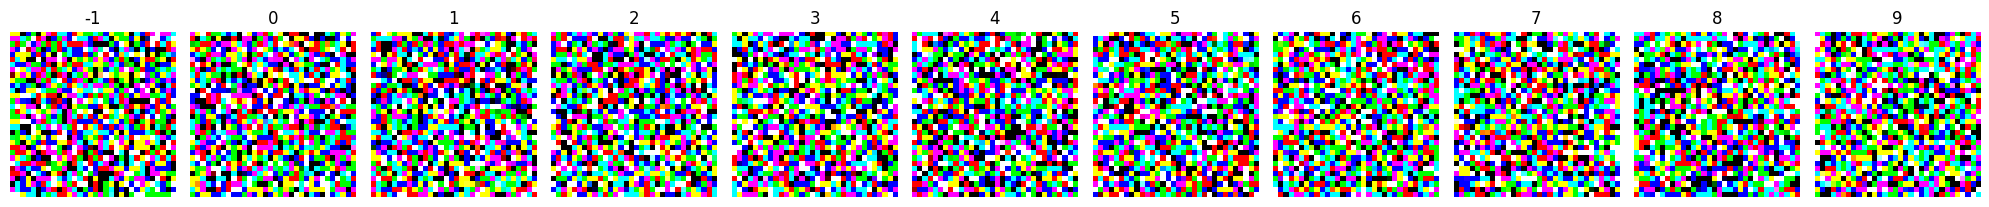

Epoch 2/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - classifier_accuracy: 0.1548 - classifier_loss: 2.2231 - loss: 0.0704 - noise_loss: 0.0513 - val_classifier_accuracy: 0.1311 - val_classifier_loss: 2.2694 - val_image_loss: 15.5508 - val_loss: 0.4839 - val_noise_loss: 0.4644 - learning_rate: 9.9606e-04


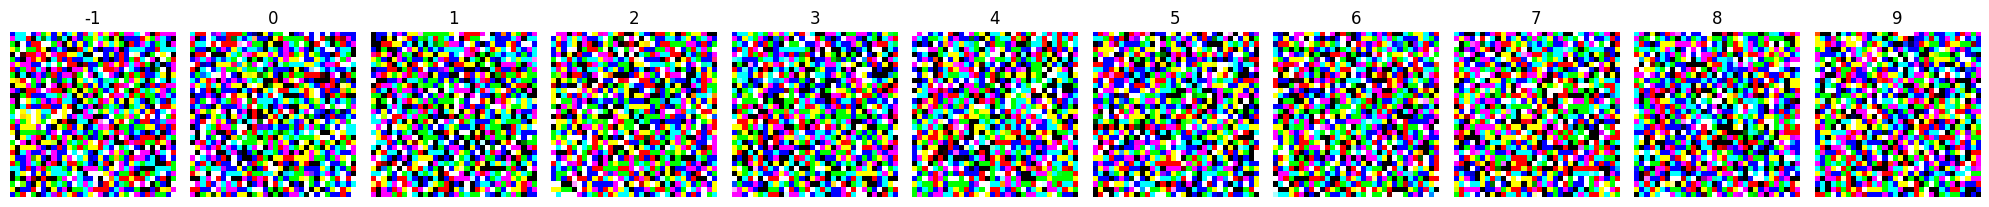

Epoch 3/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - classifier_accuracy: 0.1819 - classifier_loss: 2.1723 - loss: 0.0616 - noise_loss: 0.0430 - val_classifier_accuracy: 0.1814 - val_classifier_loss: 2.2045 - val_image_loss: 5.3425 - val_loss: 0.2505 - val_noise_loss: 0.2316 - learning_rate: 9.9114e-04


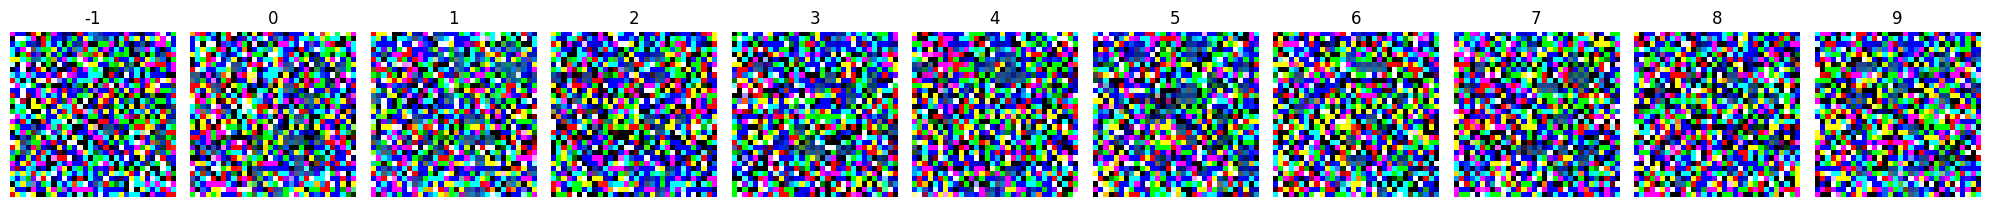

Epoch 4/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - classifier_accuracy: 0.2044 - classifier_loss: 2.1144 - loss: 0.0596 - noise_loss: 0.0414 - val_classifier_accuracy: 0.2310 - val_classifier_loss: 2.1343 - val_image_loss: 1.8636 - val_loss: 0.1559 - val_noise_loss: 0.1375 - learning_rate: 9.8429e-04


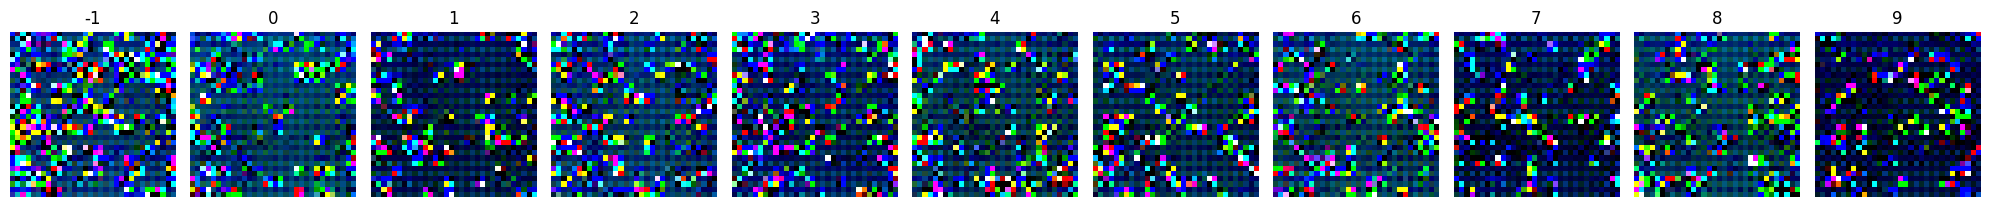

Epoch 5/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.2152 - classifier_loss: 2.0971 - loss: 0.0581 - noise_loss: 0.0400 - val_classifier_accuracy: 0.2457 - val_classifier_loss: 2.0692 - val_image_loss: 1.0790 - val_loss: 0.1082 - val_noise_loss: 0.0904 - learning_rate: 9.7553e-04


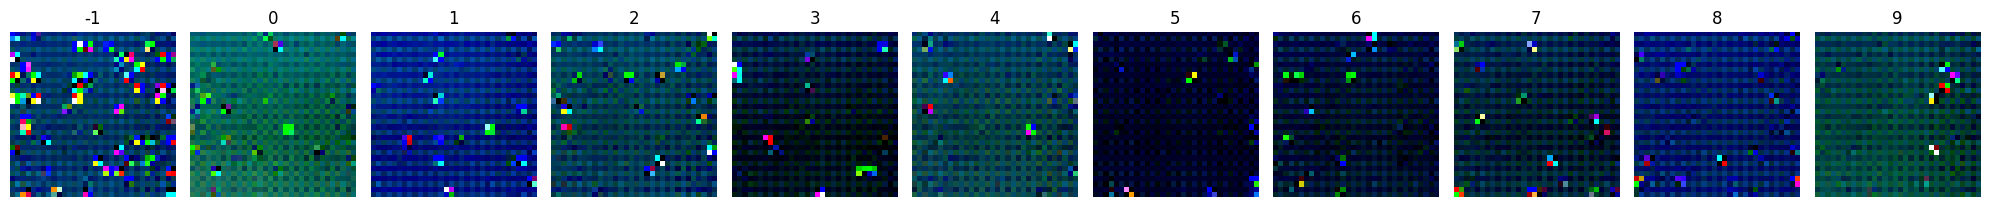

Epoch 6/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - classifier_accuracy: 0.2084 - classifier_loss: 2.0965 - loss: 0.0571 - noise_loss: 0.0390 - val_classifier_accuracy: 0.2650 - val_classifier_loss: 2.0203 - val_image_loss: 0.5623 - val_loss: 0.0830 - val_noise_loss: 0.0656 - learning_rate: 9.6489e-04


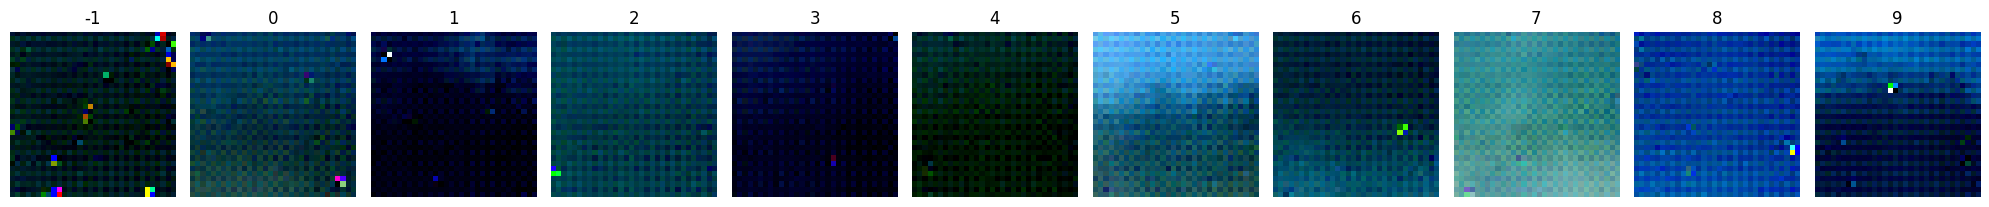

Epoch 7/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.2302 - classifier_loss: 2.0571 - loss: 0.0562 - noise_loss: 0.0385 - val_classifier_accuracy: 0.2735 - val_classifier_loss: 1.9836 - val_image_loss: 0.3927 - val_loss: 0.0694 - val_noise_loss: 0.0523 - learning_rate: 9.5241e-04


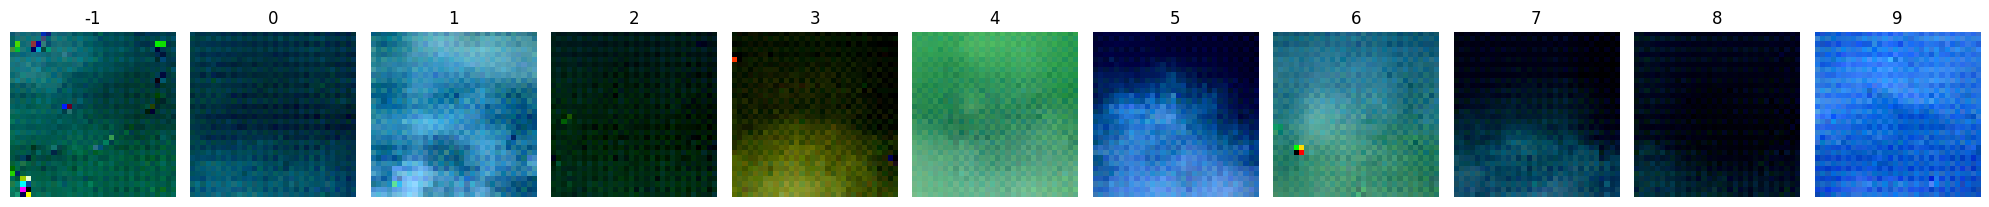

Epoch 8/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - classifier_accuracy: 0.2440 - classifier_loss: 2.0412 - loss: 0.0560 - noise_loss: 0.0384 - val_classifier_accuracy: 0.2887 - val_classifier_loss: 1.9516 - val_image_loss: 0.2471 - val_loss: 0.0620 - val_noise_loss: 0.0452 - learning_rate: 9.3815e-04


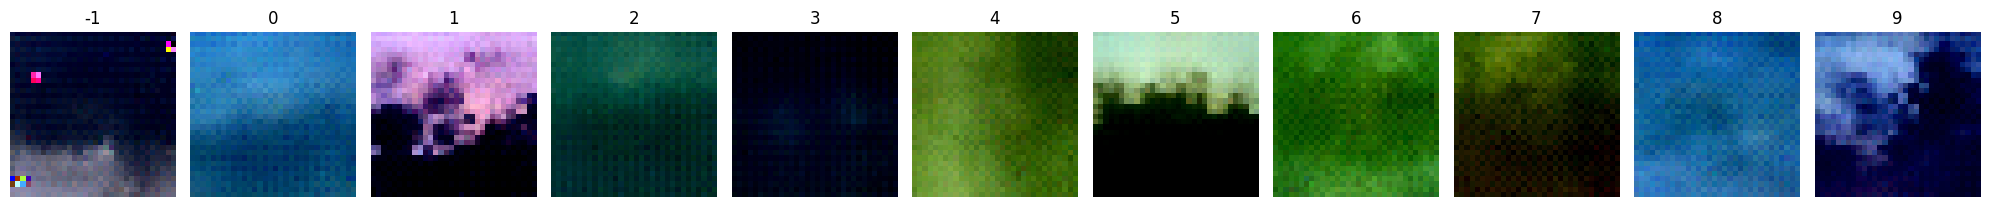

Epoch 9/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.2558 - classifier_loss: 2.0129 - loss: 0.0548 - noise_loss: 0.0375 - val_classifier_accuracy: 0.3088 - val_classifier_loss: 1.9184 - val_image_loss: 0.1885 - val_loss: 0.0581 - val_noise_loss: 0.0416 - learning_rate: 9.2216e-04


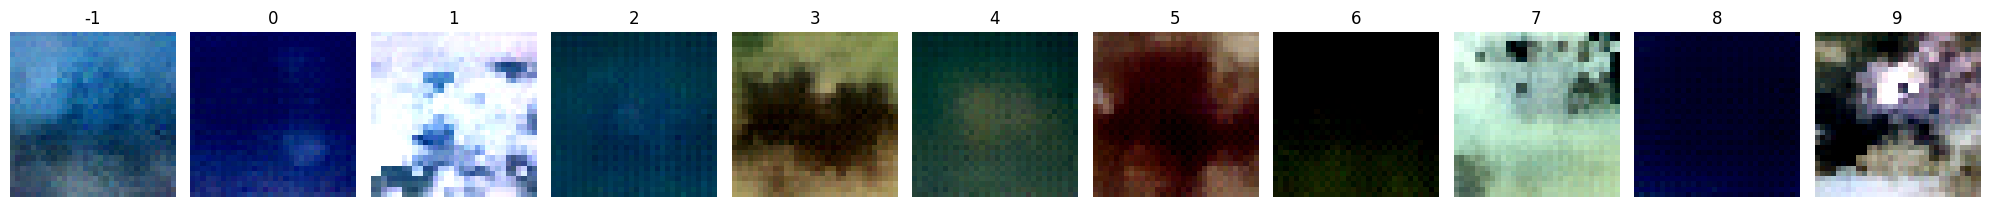

Epoch 10/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - classifier_accuracy: 0.2537 - classifier_loss: 2.0190 - loss: 0.0551 - noise_loss: 0.0378 - val_classifier_accuracy: 0.3252 - val_classifier_loss: 1.8809 - val_image_loss: 0.1481 - val_loss: 0.0567 - val_noise_loss: 0.0406 - learning_rate: 9.0451e-04


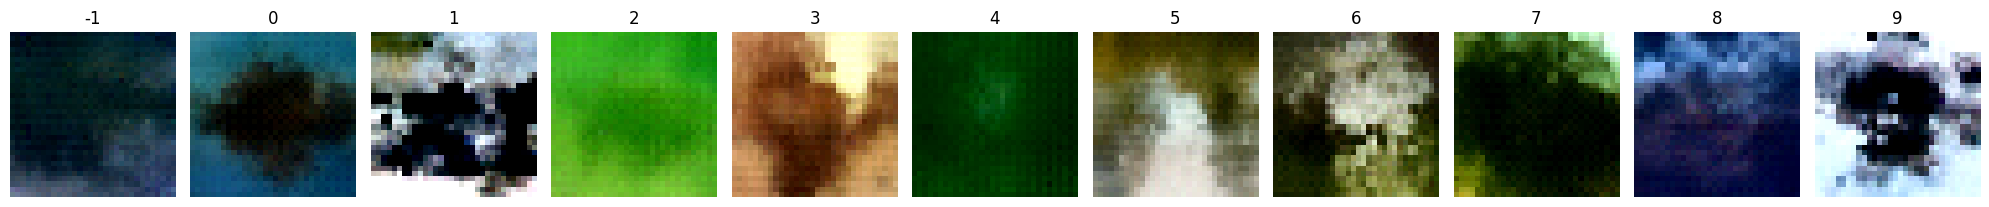

Epoch 11/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.2692 - classifier_loss: 1.9902 - loss: 0.0544 - noise_loss: 0.0373 - val_classifier_accuracy: 0.3382 - val_classifier_loss: 1.8491 - val_image_loss: 0.1309 - val_loss: 0.0549 - val_noise_loss: 0.0390 - learning_rate: 8.8526e-04


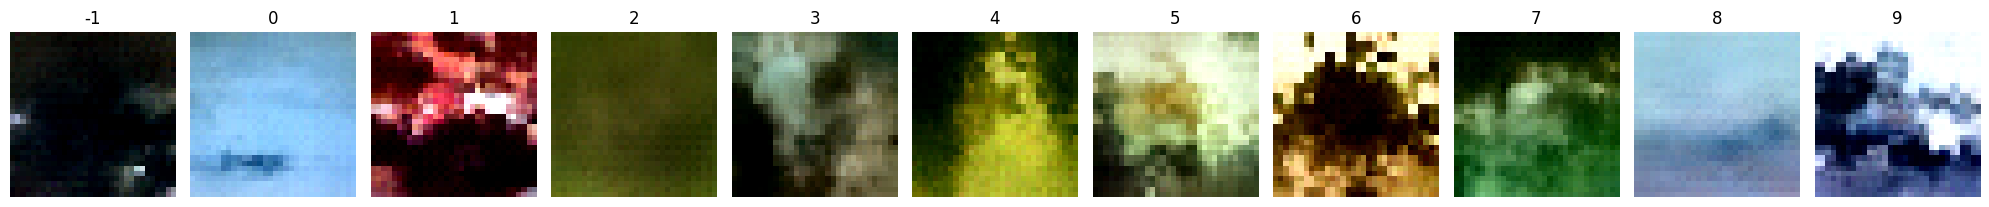

Epoch 12/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - classifier_accuracy: 0.2713 - classifier_loss: 1.9608 - loss: 0.0537 - noise_loss: 0.0369 - val_classifier_accuracy: 0.3519 - val_classifier_loss: 1.8169 - val_image_loss: 0.1331 - val_loss: 0.0536 - val_noise_loss: 0.0380 - learning_rate: 8.6448e-04


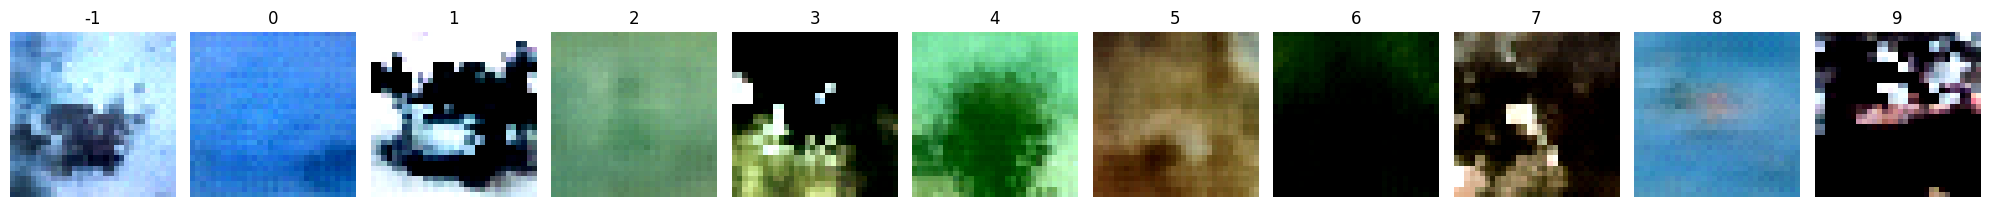

Epoch 13/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - classifier_accuracy: 0.2850 - classifier_loss: 1.9405 - loss: 0.0534 - noise_loss: 0.0367 - val_classifier_accuracy: 0.3585 - val_classifier_loss: 1.7862 - val_image_loss: 0.1299 - val_loss: 0.0533 - val_noise_loss: 0.0379 - learning_rate: 8.4227e-04


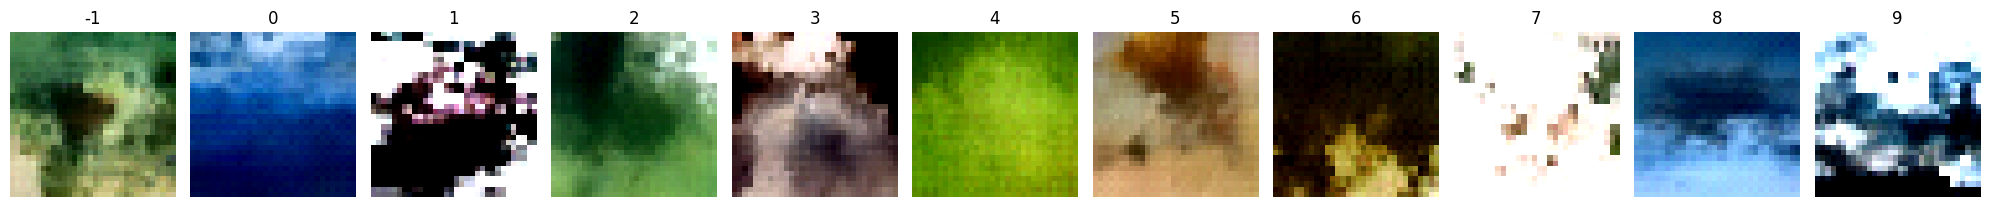

Epoch 14/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - classifier_accuracy: 0.2885 - classifier_loss: 1.9390 - loss: 0.0531 - noise_loss: 0.0364 - val_classifier_accuracy: 0.3716 - val_classifier_loss: 1.7493 - val_image_loss: 0.1245 - val_loss: 0.0531 - val_noise_loss: 0.0381 - learning_rate: 8.1871e-04


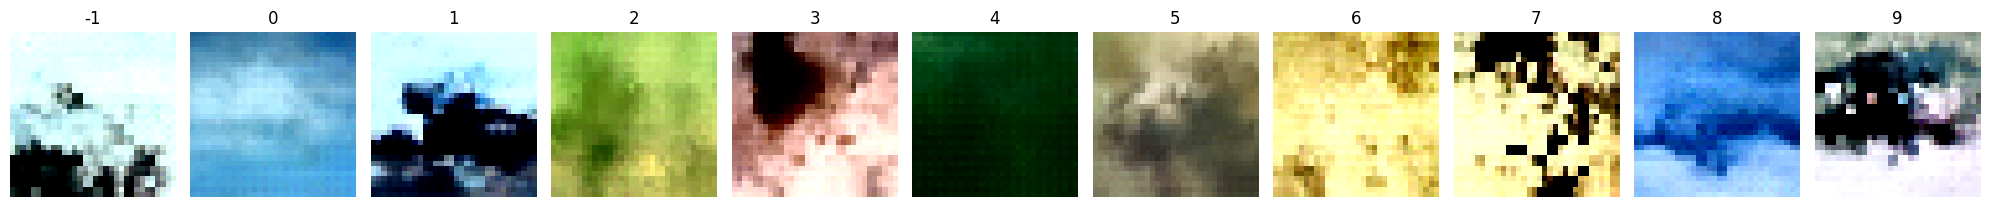

Epoch 15/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.2983 - classifier_loss: 1.9274 - loss: 0.0527 - noise_loss: 0.0361 - val_classifier_accuracy: 0.3854 - val_classifier_loss: 1.7201 - val_image_loss: 0.1220 - val_loss: 0.0518 - val_noise_loss: 0.0370 - learning_rate: 7.9389e-04


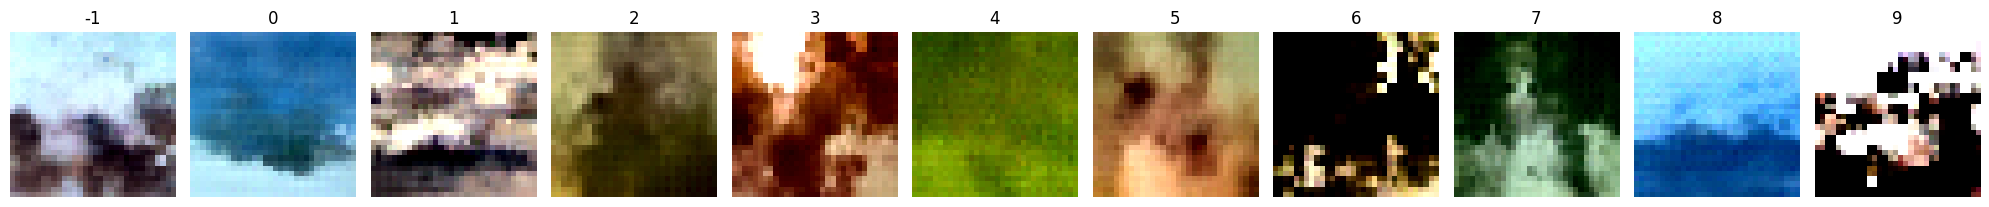

Epoch 16/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - classifier_accuracy: 0.3032 - classifier_loss: 1.9199 - loss: 0.0525 - noise_loss: 0.0359 - val_classifier_accuracy: 0.3920 - val_classifier_loss: 1.6992 - val_image_loss: 0.1220 - val_loss: 0.0517 - val_noise_loss: 0.0371 - learning_rate: 7.6791e-04


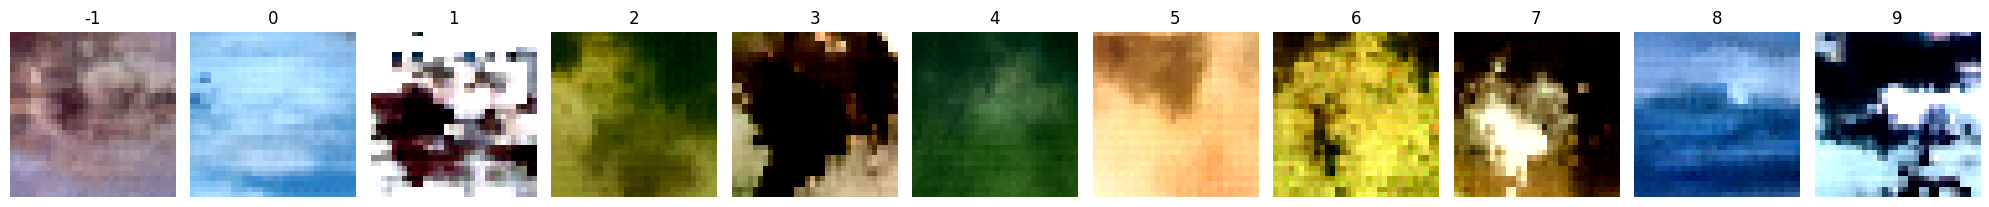

Epoch 17/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - classifier_accuracy: 0.2966 - classifier_loss: 1.9160 - loss: 0.0523 - noise_loss: 0.0358 - val_classifier_accuracy: 0.3994 - val_classifier_loss: 1.6776 - val_image_loss: 0.1156 - val_loss: 0.0515 - val_noise_loss: 0.0371 - learning_rate: 7.4088e-04


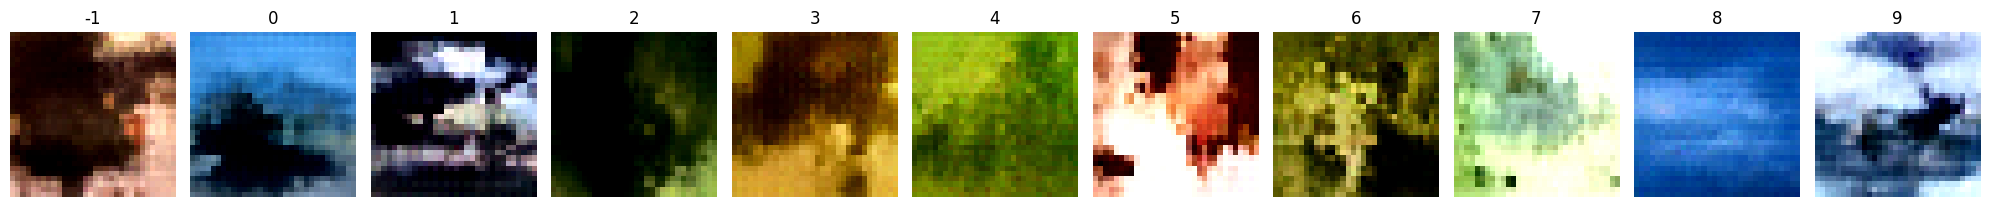

Epoch 18/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - classifier_accuracy: 0.3064 - classifier_loss: 1.8807 - loss: 0.0515 - noise_loss: 0.0353 - val_classifier_accuracy: 0.4048 - val_classifier_loss: 1.6644 - val_image_loss: 0.1216 - val_loss: 0.0514 - val_noise_loss: 0.0371 - learning_rate: 7.1289e-04


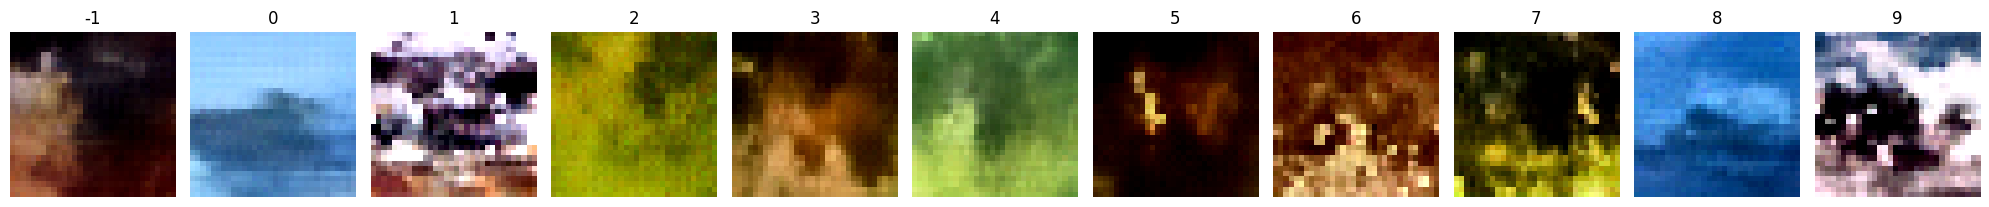

Epoch 19/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - classifier_accuracy: 0.3040 - classifier_loss: 1.9027 - loss: 0.0516 - noise_loss: 0.0353 - val_classifier_accuracy: 0.4082 - val_classifier_loss: 1.6487 - val_image_loss: 0.1216 - val_loss: 0.0508 - val_noise_loss: 0.0366 - learning_rate: 6.8406e-04


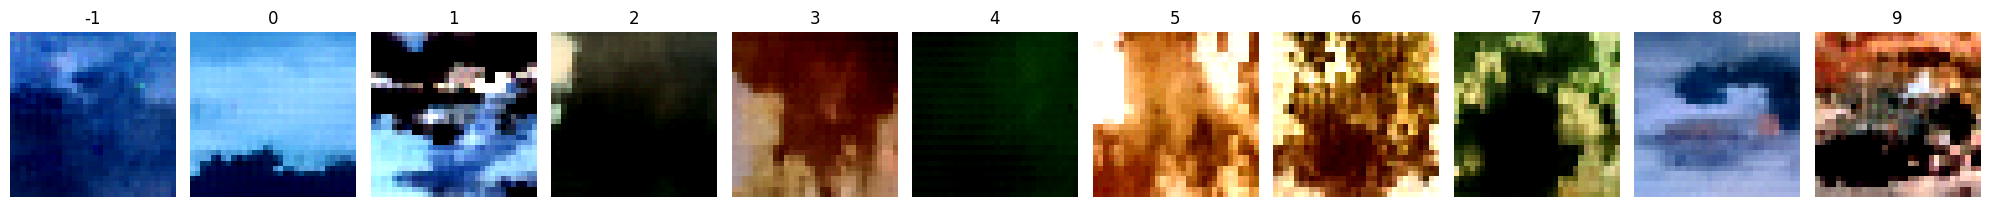

Epoch 20/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - classifier_accuracy: 0.3119 - classifier_loss: 1.8892 - loss: 0.0514 - noise_loss: 0.0351 - val_classifier_accuracy: 0.4142 - val_classifier_loss: 1.6296 - val_image_loss: 0.1165 - val_loss: 0.0503 - val_noise_loss: 0.0362 - learning_rate: 6.5451e-04


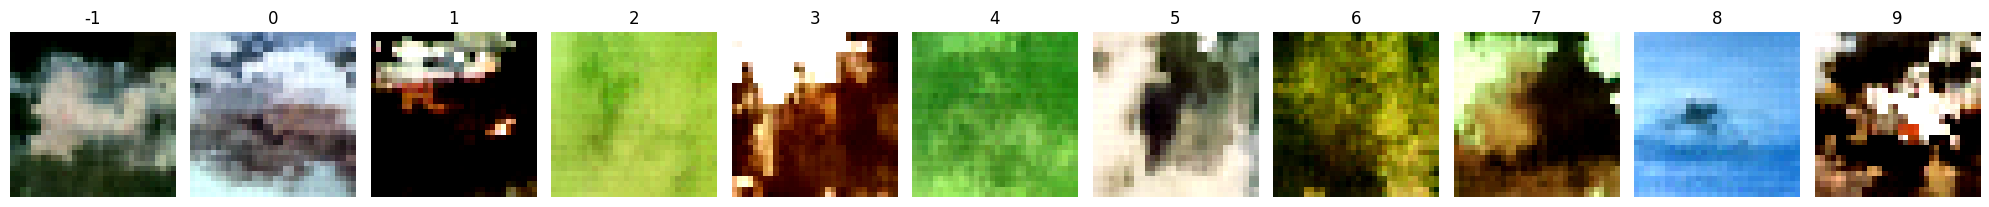

Epoch 21/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - classifier_accuracy: 0.3088 - classifier_loss: 1.8797 - loss: 0.0510 - noise_loss: 0.0348 - val_classifier_accuracy: 0.4221 - val_classifier_loss: 1.6110 - val_image_loss: 0.1222 - val_loss: 0.0505 - val_noise_loss: 0.0366 - learning_rate: 6.2435e-04


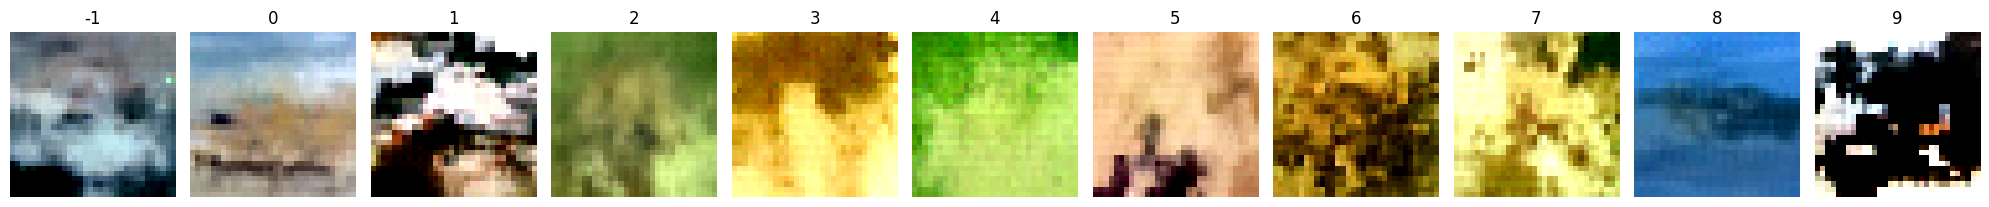

Epoch 22/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - classifier_accuracy: 0.3186 - classifier_loss: 1.8618 - loss: 0.0507 - noise_loss: 0.0347 - val_classifier_accuracy: 0.4263 - val_classifier_loss: 1.5928 - val_image_loss: 0.1219 - val_loss: 0.0498 - val_noise_loss: 0.0361 - learning_rate: 5.9369e-04


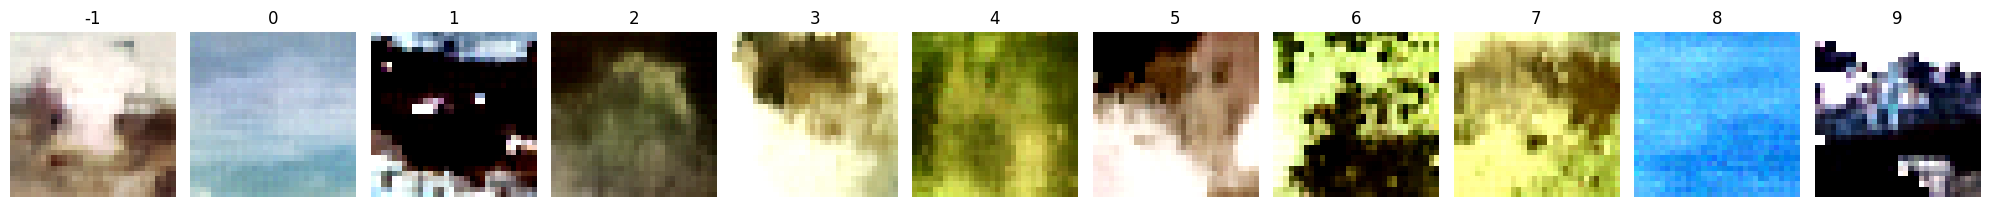

Epoch 23/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - classifier_accuracy: 0.3297 - classifier_loss: 1.8364 - loss: 0.0504 - noise_loss: 0.0346 - val_classifier_accuracy: 0.4276 - val_classifier_loss: 1.5824 - val_image_loss: 0.1196 - val_loss: 0.0497 - val_noise_loss: 0.0361 - learning_rate: 5.6267e-04


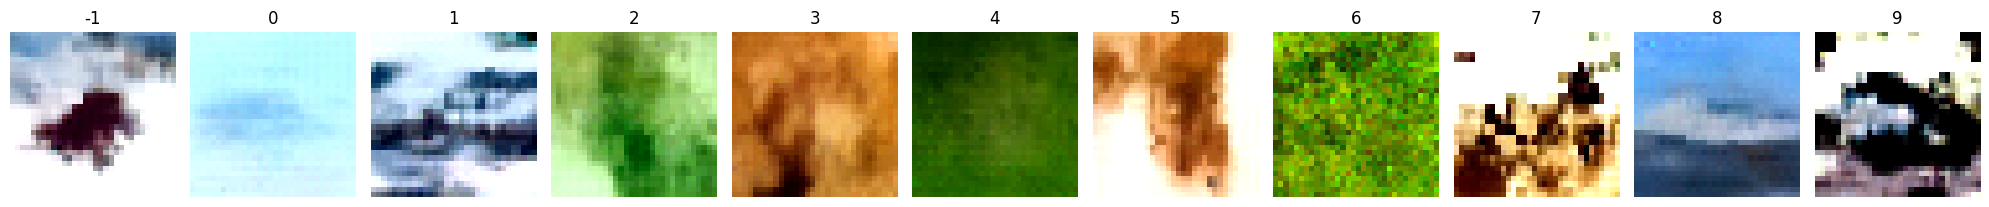

Epoch 24/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - classifier_accuracy: 0.3247 - classifier_loss: 1.8606 - loss: 0.0506 - noise_loss: 0.0345 - val_classifier_accuracy: 0.4336 - val_classifier_loss: 1.5680 - val_image_loss: 0.1204 - val_loss: 0.0495 - val_noise_loss: 0.0360 - learning_rate: 5.3140e-04


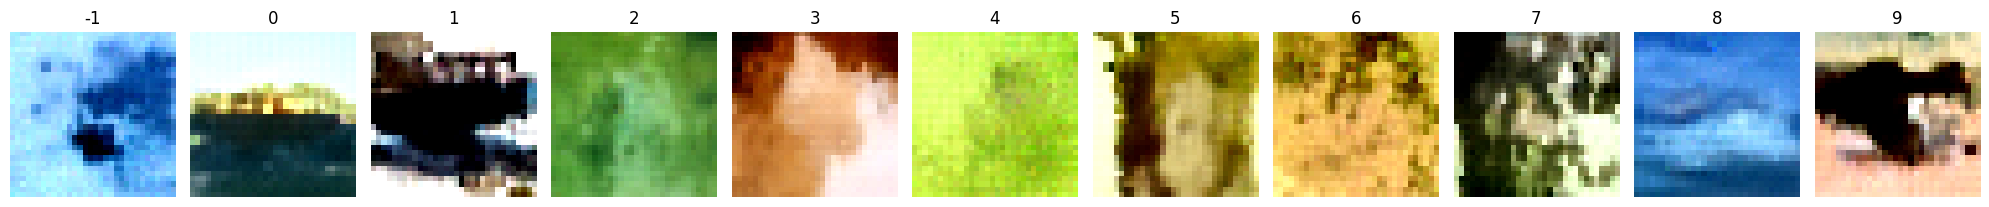

Epoch 25/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - classifier_accuracy: 0.3292 - classifier_loss: 1.8304 - loss: 0.0501 - noise_loss: 0.0343 - val_classifier_accuracy: 0.4382 - val_classifier_loss: 1.5567 - val_image_loss: 0.1162 - val_loss: 0.0491 - val_noise_loss: 0.0358 - learning_rate: 5.0000e-04


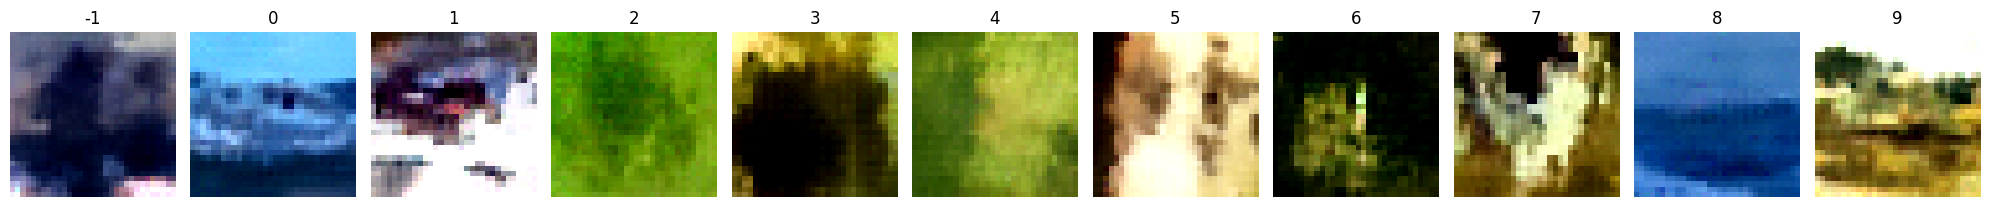

Epoch 26/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - classifier_accuracy: 0.3277 - classifier_loss: 1.8406 - loss: 0.0502 - noise_loss: 0.0344 - val_classifier_accuracy: 0.4419 - val_classifier_loss: 1.5458 - val_image_loss: 0.1104 - val_loss: 0.0494 - val_noise_loss: 0.0361 - learning_rate: 4.6860e-04


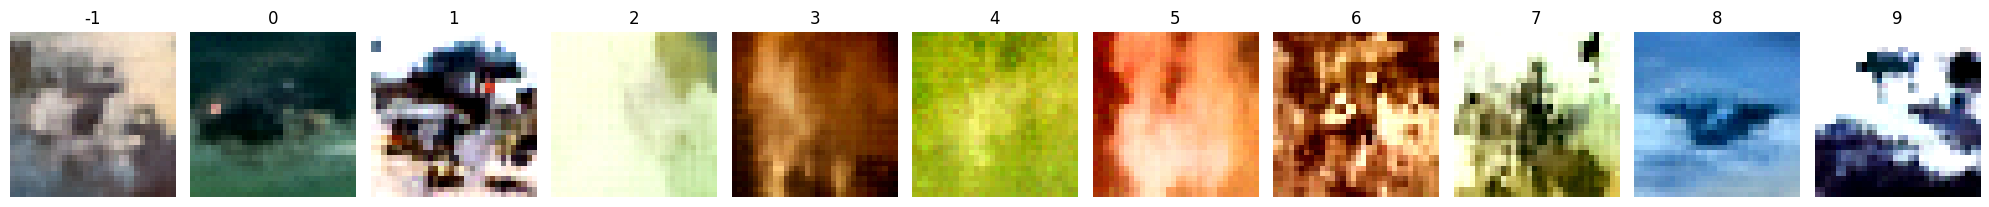

Epoch 27/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - classifier_accuracy: 0.3362 - classifier_loss: 1.8165 - loss: 0.0499 - noise_loss: 0.0342 - val_classifier_accuracy: 0.4415 - val_classifier_loss: 1.5368 - val_image_loss: 0.1201 - val_loss: 0.0491 - val_noise_loss: 0.0359 - learning_rate: 4.3733e-04


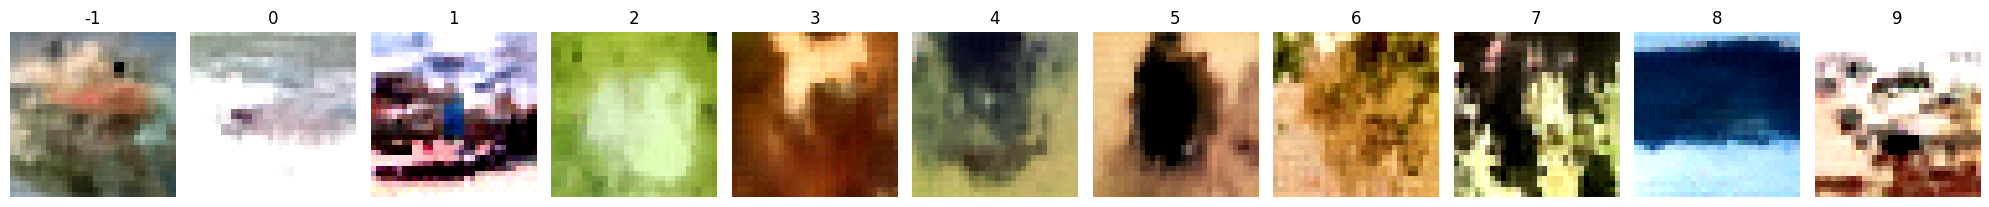

Epoch 28/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - classifier_accuracy: 0.3244 - classifier_loss: 1.8177 - loss: 0.0496 - noise_loss: 0.0339 - val_classifier_accuracy: 0.4430 - val_classifier_loss: 1.5277 - val_image_loss: 0.1104 - val_loss: 0.0489 - val_noise_loss: 0.0358 - learning_rate: 4.0631e-04


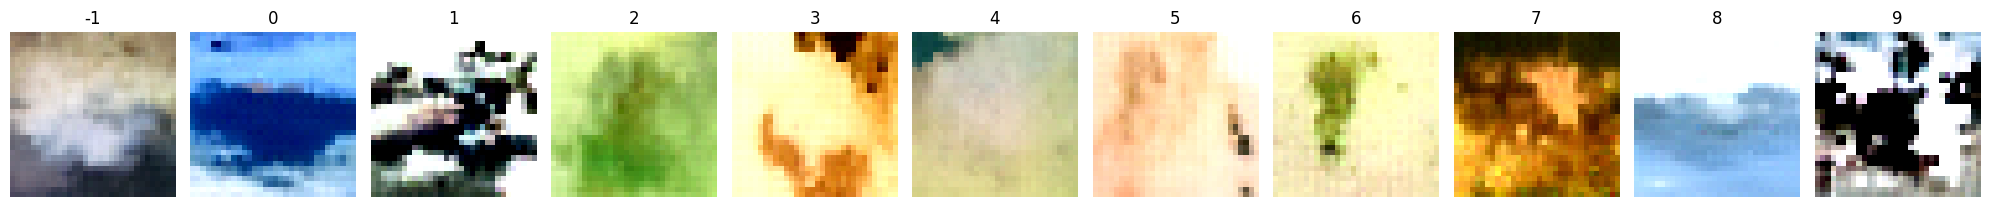

Epoch 29/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - classifier_accuracy: 0.3298 - classifier_loss: 1.8112 - loss: 0.0496 - noise_loss: 0.0341 - val_classifier_accuracy: 0.4463 - val_classifier_loss: 1.5175 - val_image_loss: 0.1135 - val_loss: 0.0487 - val_noise_loss: 0.0356 - learning_rate: 3.7566e-04


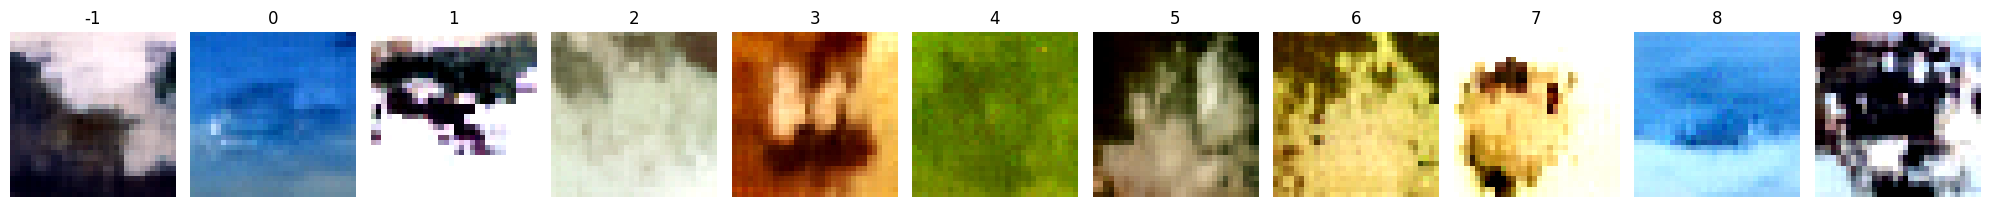

Epoch 30/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - classifier_accuracy: 0.3561 - classifier_loss: 1.7817 - loss: 0.0494 - noise_loss: 0.0341 - val_classifier_accuracy: 0.4505 - val_classifier_loss: 1.5080 - val_image_loss: 0.1111 - val_loss: 0.0484 - val_noise_loss: 0.0354 - learning_rate: 3.4549e-04


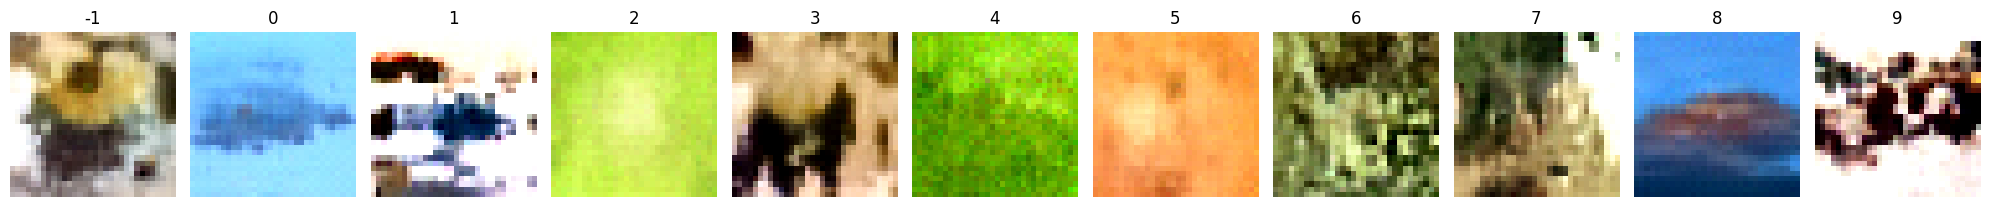

Epoch 31/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - classifier_accuracy: 0.3409 - classifier_loss: 1.8008 - loss: 0.0496 - noise_loss: 0.0341 - val_classifier_accuracy: 0.4501 - val_classifier_loss: 1.5012 - val_image_loss: 0.1182 - val_loss: 0.0477 - val_noise_loss: 0.0348 - learning_rate: 3.1594e-04


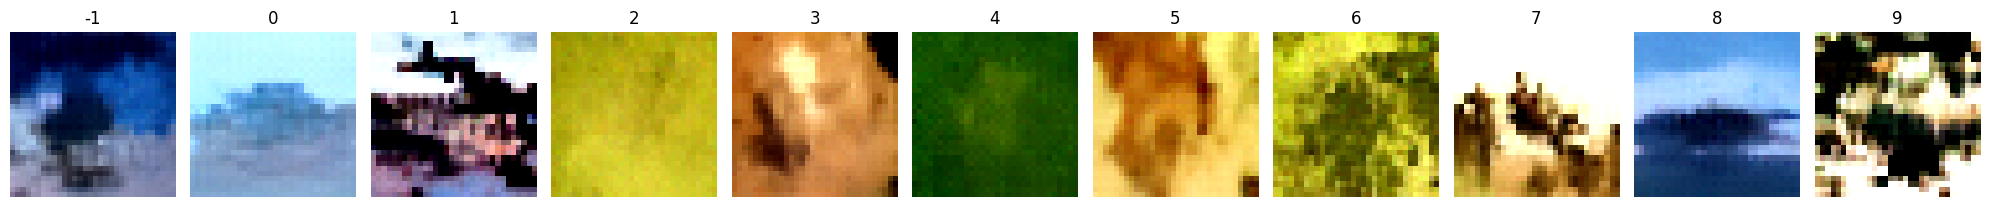

Epoch 32/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - classifier_accuracy: 0.3458 - classifier_loss: 1.7688 - loss: 0.0488 - noise_loss: 0.0336 - val_classifier_accuracy: 0.4541 - val_classifier_loss: 1.4947 - val_image_loss: 0.1140 - val_loss: 0.0482 - val_noise_loss: 0.0353 - learning_rate: 2.8711e-04


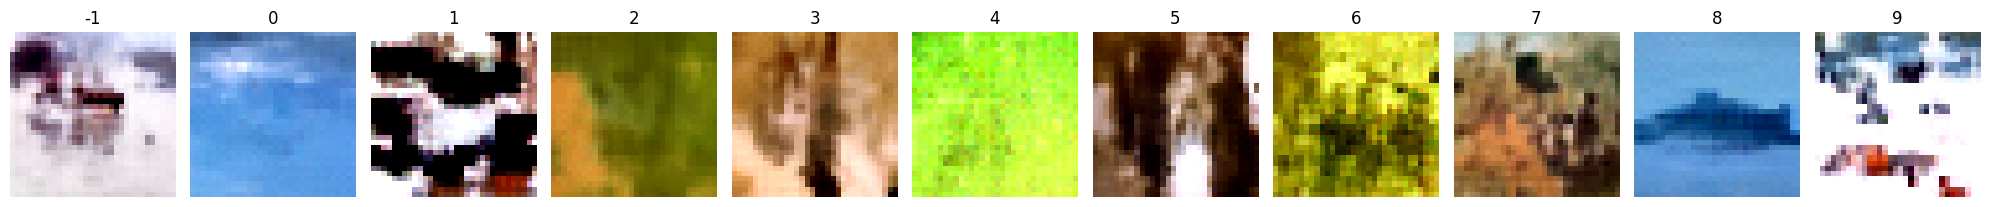

Epoch 33/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.3531 - classifier_loss: 1.7647 - loss: 0.0489 - noise_loss: 0.0337 - val_classifier_accuracy: 0.4567 - val_classifier_loss: 1.4859 - val_image_loss: 0.1122 - val_loss: 0.0491 - val_noise_loss: 0.0363 - learning_rate: 2.5912e-04


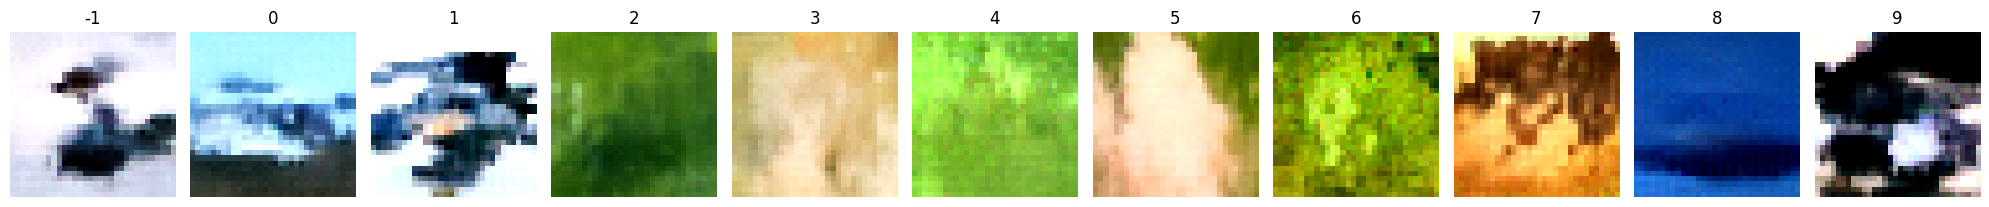

Epoch 34/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - classifier_accuracy: 0.3511 - classifier_loss: 1.7738 - loss: 0.0489 - noise_loss: 0.0336 - val_classifier_accuracy: 0.4600 - val_classifier_loss: 1.4787 - val_image_loss: 0.1144 - val_loss: 0.0486 - val_noise_loss: 0.0359 - learning_rate: 2.3209e-04


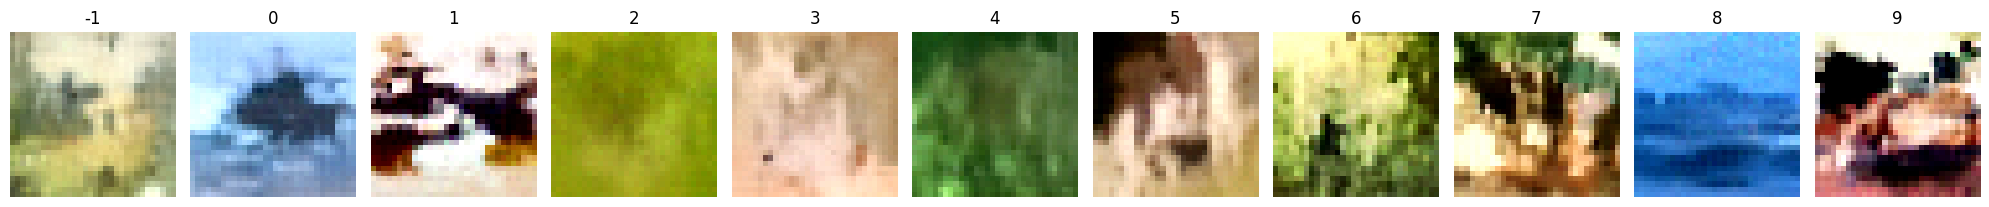

Epoch 35/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - classifier_accuracy: 0.3573 - classifier_loss: 1.7577 - loss: 0.0488 - noise_loss: 0.0336 - val_classifier_accuracy: 0.4618 - val_classifier_loss: 1.4739 - val_image_loss: 0.1165 - val_loss: 0.0478 - val_noise_loss: 0.0351 - learning_rate: 2.0611e-04


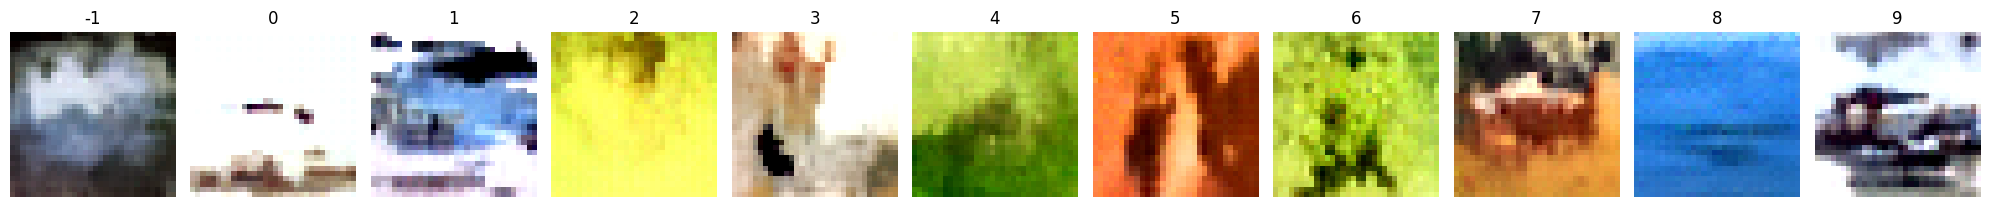

Epoch 36/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - classifier_accuracy: 0.3672 - classifier_loss: 1.7494 - loss: 0.0489 - noise_loss: 0.0338 - val_classifier_accuracy: 0.4628 - val_classifier_loss: 1.4716 - val_image_loss: 0.1150 - val_loss: 0.0482 - val_noise_loss: 0.0355 - learning_rate: 1.8129e-04


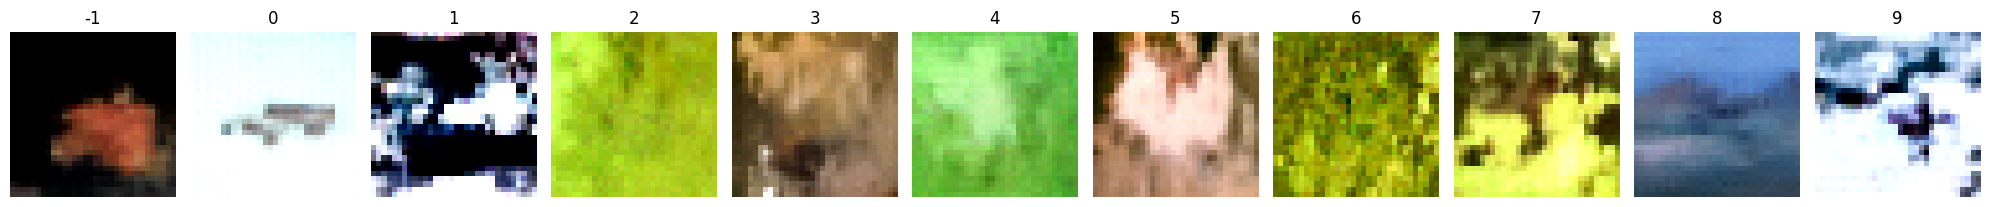

Epoch 37/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - classifier_accuracy: 0.3563 - classifier_loss: 1.7517 - loss: 0.0486 - noise_loss: 0.0335 - val_classifier_accuracy: 0.4621 - val_classifier_loss: 1.4704 - val_image_loss: 0.1155 - val_loss: 0.0482 - val_noise_loss: 0.0355 - learning_rate: 1.5773e-04


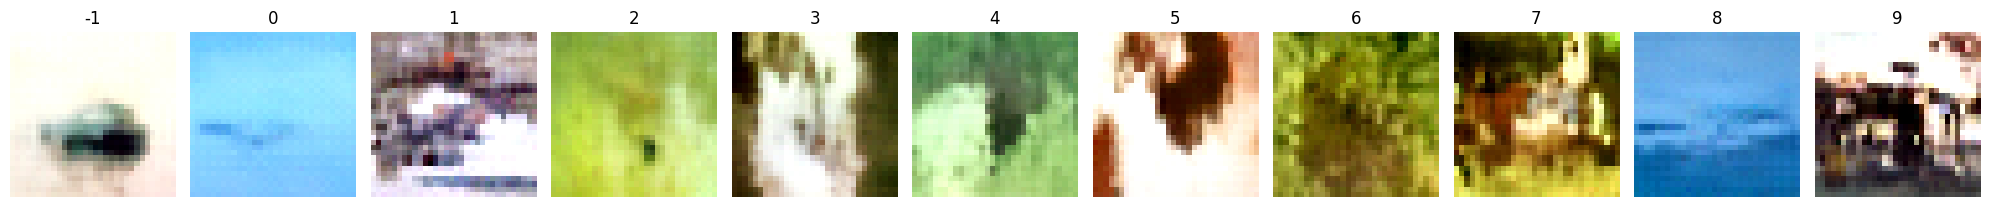

Epoch 38/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.3599 - classifier_loss: 1.7490 - loss: 0.0487 - noise_loss: 0.0337 - val_classifier_accuracy: 0.4633 - val_classifier_loss: 1.4642 - val_image_loss: 0.1153 - val_loss: 0.0483 - val_noise_loss: 0.0358 - learning_rate: 1.3552e-04


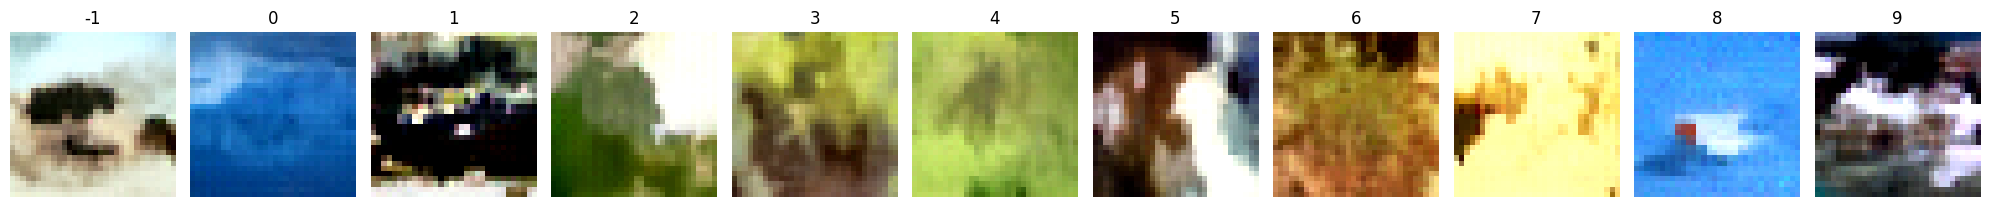

Epoch 39/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.3608 - classifier_loss: 1.7465 - loss: 0.0486 - noise_loss: 0.0335 - val_classifier_accuracy: 0.4656 - val_classifier_loss: 1.4624 - val_image_loss: 0.1162 - val_loss: 0.0482 - val_noise_loss: 0.0356 - learning_rate: 1.1474e-04


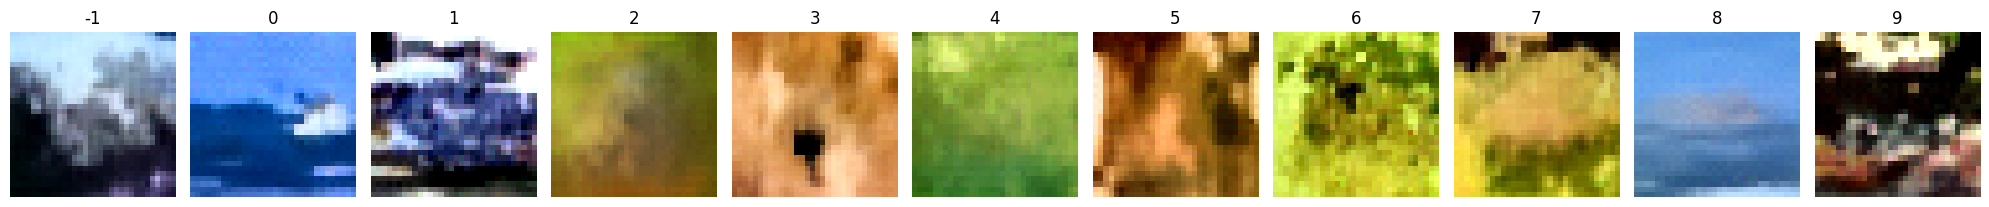

Epoch 40/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - classifier_accuracy: 0.3676 - classifier_loss: 1.7182 - loss: 0.0484 - noise_loss: 0.0337 - val_classifier_accuracy: 0.4653 - val_classifier_loss: 1.4582 - val_image_loss: 0.1138 - val_loss: 0.0483 - val_noise_loss: 0.0358 - learning_rate: 9.5491e-05


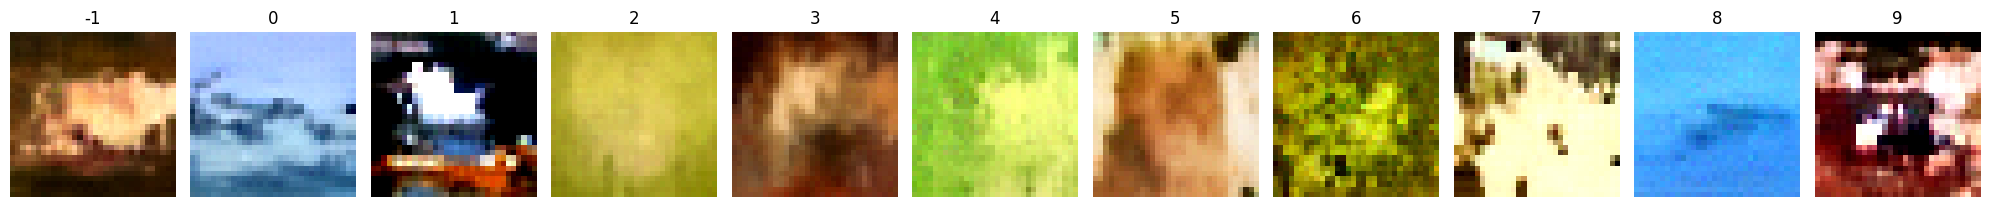

Epoch 41/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - classifier_accuracy: 0.3536 - classifier_loss: 1.7420 - loss: 0.0486 - noise_loss: 0.0336 - val_classifier_accuracy: 0.4681 - val_classifier_loss: 1.4541 - val_image_loss: 0.1115 - val_loss: 0.0482 - val_noise_loss: 0.0357 - learning_rate: 7.7836e-05


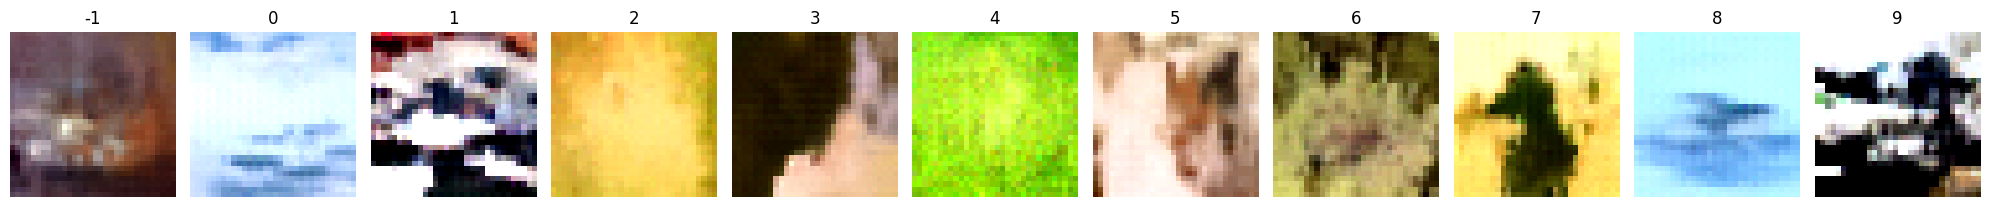

Epoch 42/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - classifier_accuracy: 0.3665 - classifier_loss: 1.7262 - loss: 0.0483 - noise_loss: 0.0335 - val_classifier_accuracy: 0.4707 - val_classifier_loss: 1.4501 - val_image_loss: 0.1129 - val_loss: 0.0483 - val_noise_loss: 0.0359 - learning_rate: 6.1847e-05


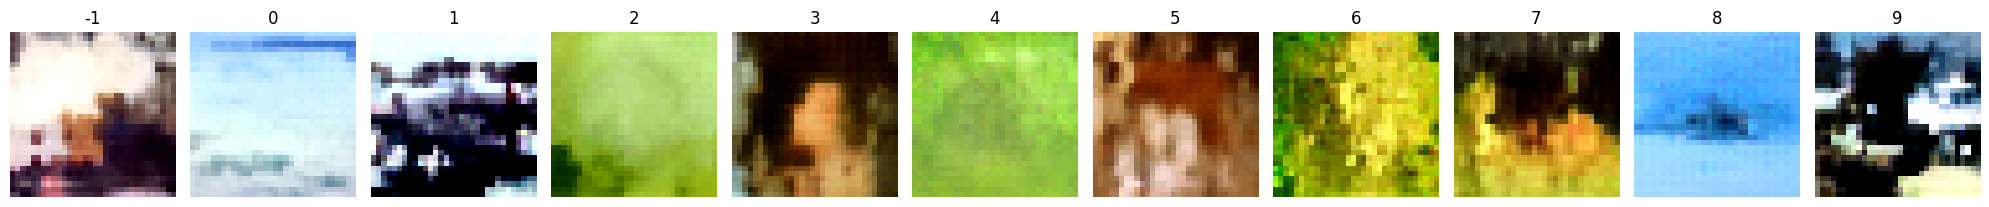

Epoch 43/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - classifier_accuracy: 0.3686 - classifier_loss: 1.7366 - loss: 0.0485 - noise_loss: 0.0335 - val_classifier_accuracy: 0.4719 - val_classifier_loss: 1.4465 - val_image_loss: 0.1140 - val_loss: 0.0481 - val_noise_loss: 0.0356 - learning_rate: 4.7586e-05


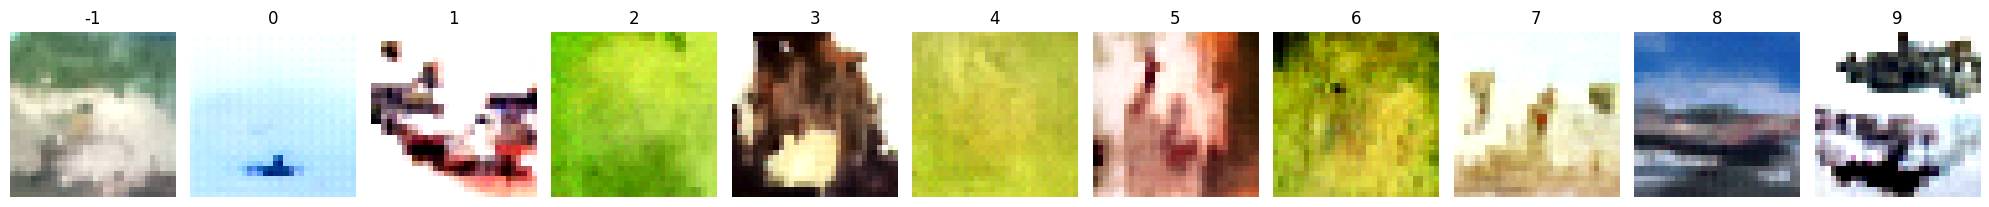

Epoch 44/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - classifier_accuracy: 0.3689 - classifier_loss: 1.7441 - loss: 0.0484 - noise_loss: 0.0333 - val_classifier_accuracy: 0.4718 - val_classifier_loss: 1.4436 - val_image_loss: 0.1079 - val_loss: 0.0485 - val_noise_loss: 0.0361 - learning_rate: 3.5112e-05


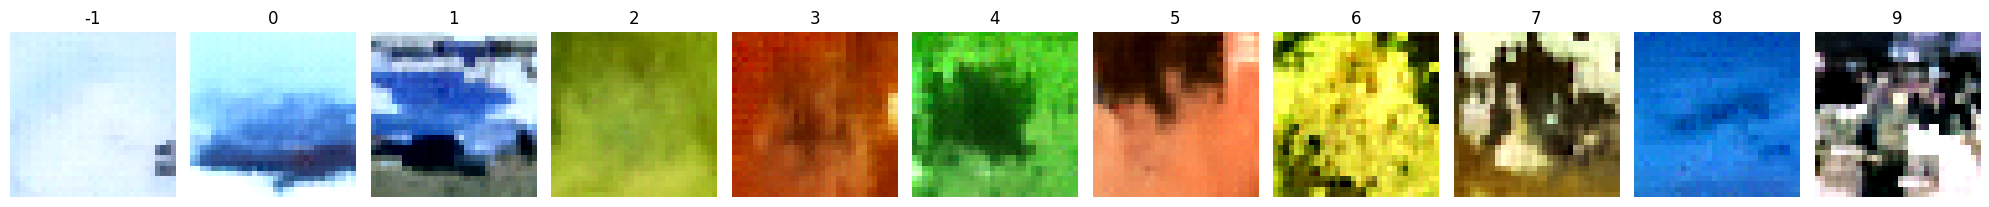

Epoch 45/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - classifier_accuracy: 0.3629 - classifier_loss: 1.7260 - loss: 0.0482 - noise_loss: 0.0334 - val_classifier_accuracy: 0.4721 - val_classifier_loss: 1.4410 - val_image_loss: 0.1134 - val_loss: 0.0479 - val_noise_loss: 0.0356 - learning_rate: 2.4472e-05


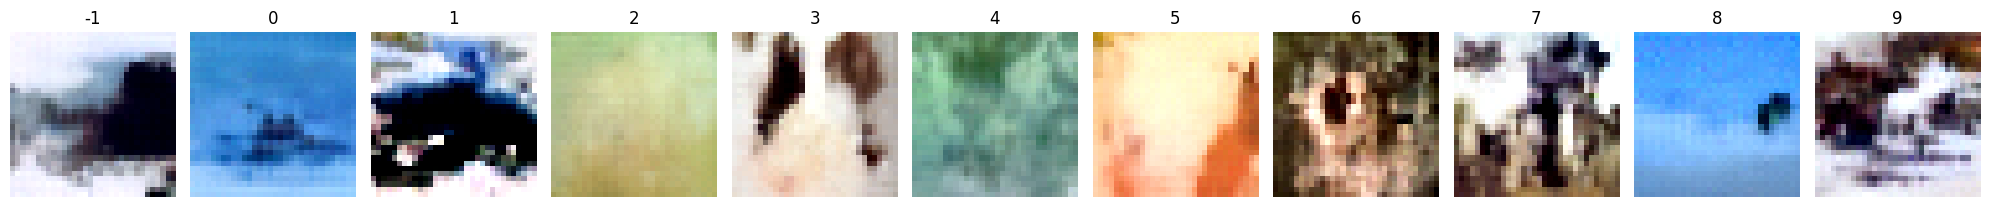

Epoch 46/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.3706 - classifier_loss: 1.7122 - loss: 0.0479 - noise_loss: 0.0331 - val_classifier_accuracy: 0.4739 - val_classifier_loss: 1.4387 - val_image_loss: 0.1123 - val_loss: 0.0475 - val_noise_loss: 0.0351 - learning_rate: 1.5708e-05


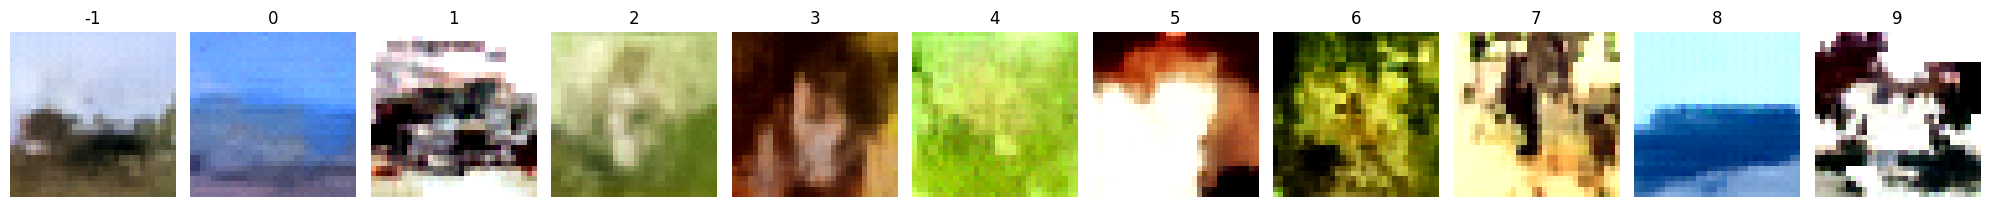

Epoch 47/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - classifier_accuracy: 0.3626 - classifier_loss: 1.7359 - loss: 0.0482 - noise_loss: 0.0333 - val_classifier_accuracy: 0.4749 - val_classifier_loss: 1.4372 - val_image_loss: 0.1095 - val_loss: 0.0485 - val_noise_loss: 0.0361 - learning_rate: 8.8564e-06


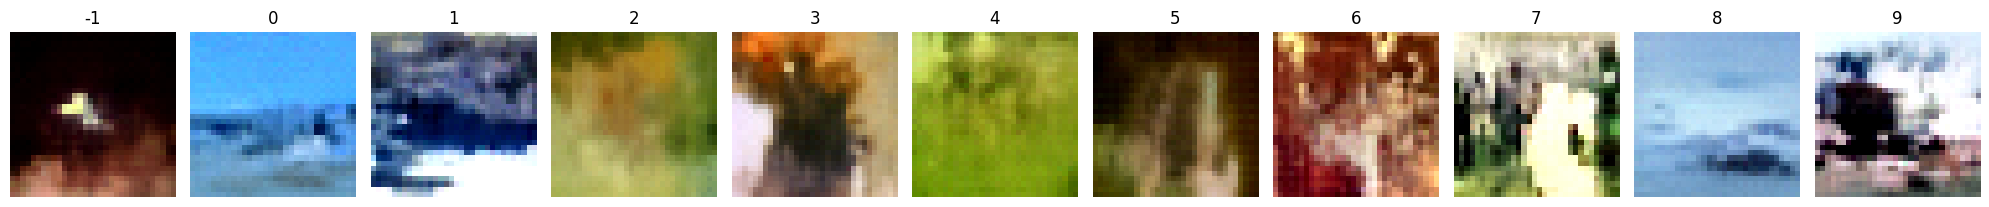

Epoch 48/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - classifier_accuracy: 0.3758 - classifier_loss: 1.7093 - loss: 0.0478 - noise_loss: 0.0332 - val_classifier_accuracy: 0.4762 - val_classifier_loss: 1.4359 - val_image_loss: 0.1123 - val_loss: 0.0473 - val_noise_loss: 0.0350 - learning_rate: 3.9426e-06


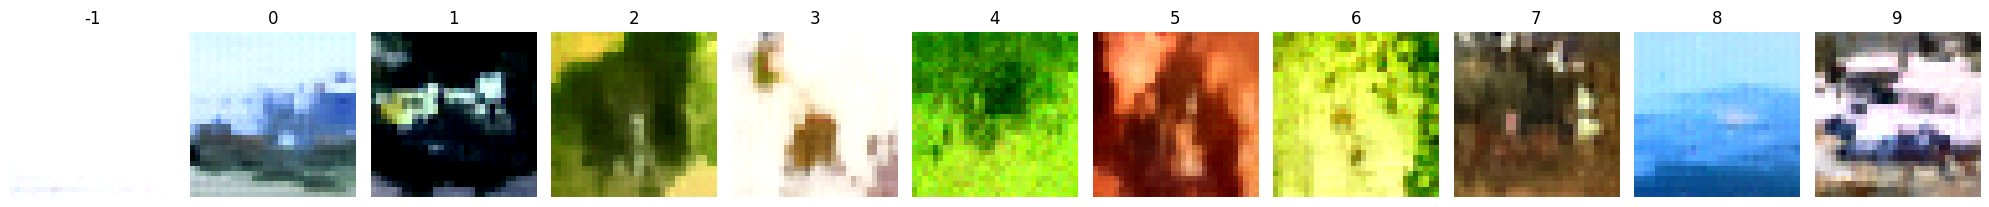

Epoch 49/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.3741 - classifier_loss: 1.7231 - loss: 0.0481 - noise_loss: 0.0333 - val_classifier_accuracy: 0.4749 - val_classifier_loss: 1.4352 - val_image_loss: 0.1114 - val_loss: 0.0481 - val_noise_loss: 0.0358 - learning_rate: 9.8664e-07


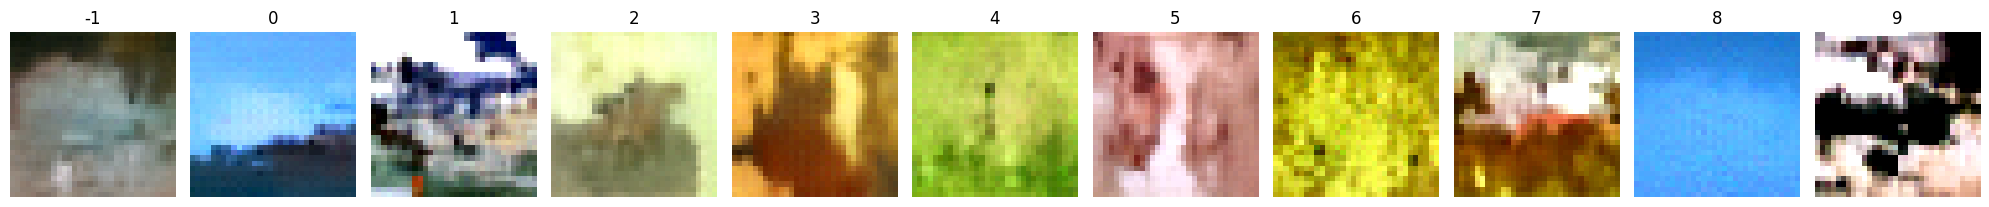

Epoch 50/50
390/390 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - classifier_accuracy: 0.3744 - classifier_loss: 1.7018 - loss: 0.0481 - noise_loss: 0.0335 - val_classifier_accuracy: 0.4752 - val_classifier_loss: 1.4347 - val_image_loss: 0.1116 - val_loss: 0.0477 - val_noise_loss: 0.0354 - learning_rate: 0.0000e+00


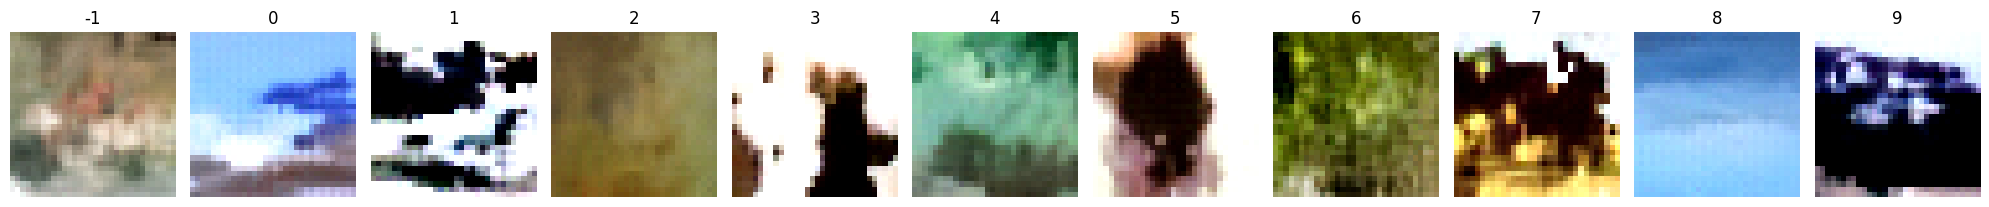

In [9]:
history = model.fit(
    trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list
).history

In [10]:
model.save_weights("./models/CIFAR10 DiTCLF/model.weights.h5")

In [11]:
model.evaluate(valset, network_name="ema")

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - classifier_accuracy: 0.4752 - classifier_loss: 1.4347 - image_loss: 0.1119 - loss: 0.0480 - noise_loss: 0.0357


[<tf.Tensor: shape=(), dtype=float32, numpy=0.048031702637672424>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.035693131387233734>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.11189863830804825>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1.4347174167633057>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.47520002722740173>]

In [12]:
model.evaluate(valset, network_name="raw")

79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - classifier_accuracy: 0.4755 - classifier_loss: 1.4340 - image_loss: 0.1107 - loss: 0.0480 - noise_loss: 0.0356


[<tf.Tensor: shape=(), dtype=float32, numpy=0.04797620698809624>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.03564412146806717>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.11066433787345886>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1.4339631795883179>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.4755000174045563>]

In [13]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=256
)

Step (79/79) --- Ensemble Accuracy: 0.4818


2026-09-18 00:38:26.535193: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


0.48179998993873596

In [14]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=128
)

Step (79/79) --- Ensemble Accuracy: 0.4830


2026-09-18 00:48:20.551607: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


0.4830000102519989

In [15]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=64
)

Step (79/79) --- Ensemble Accuracy: 0.4830


0.4830000102519989

In [16]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=32
)

Step (79/79) --- Ensemble Accuracy: 0.4800


2026-09-18 00:56:01.353203: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


0.47999998927116394

In [17]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=16
)

Step (79/79) --- Ensemble Accuracy: 0.4789


0.4788999855518341

In [18]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=8
)

Step (79/79) --- Ensemble Accuracy: 0.4785


0.47850000858306885

In [19]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=4
)

Step (79/79) --- Ensemble Accuracy: 0.4756


0.475600004196167

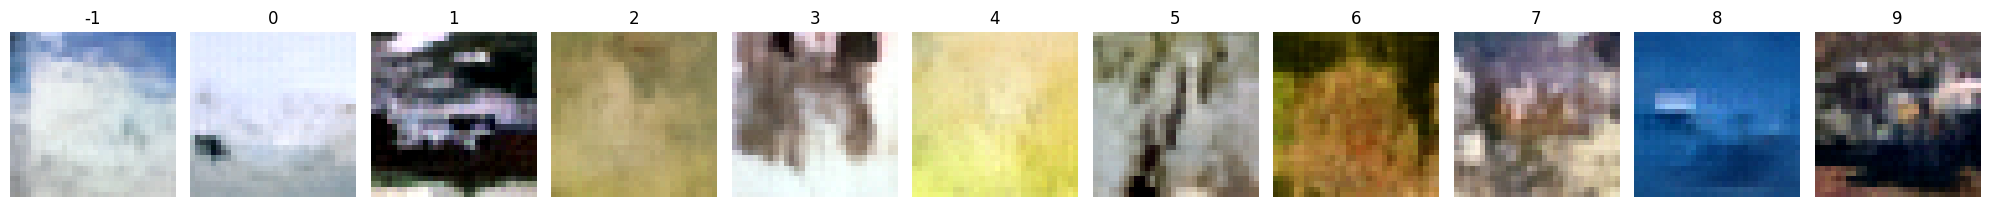

In [20]:
from common.utils import plot_images


imgs = model.sample(add_null_label=True, scale=3., eta=1., steps=1_000)
plot_images(imgs, has_null_label=True)

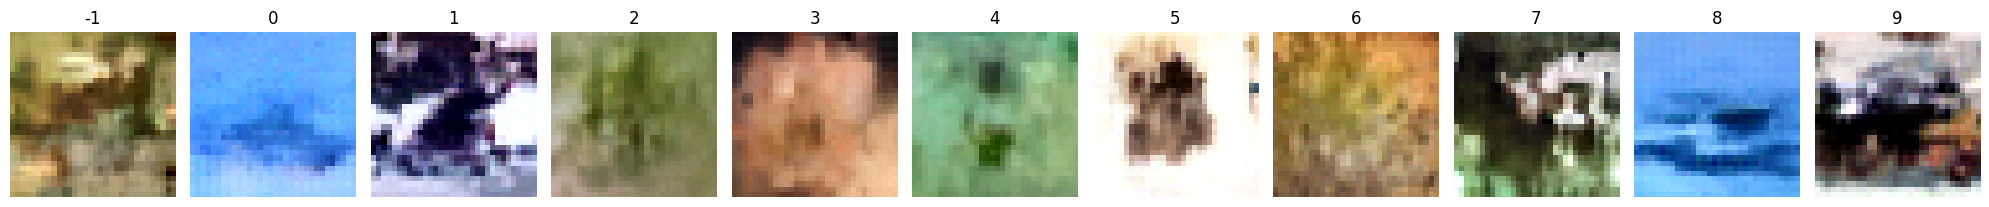

In [21]:
imgs = model.sample(add_null_label=True, scale=3., steps=1_000)
plot_images(imgs, has_null_label=True)

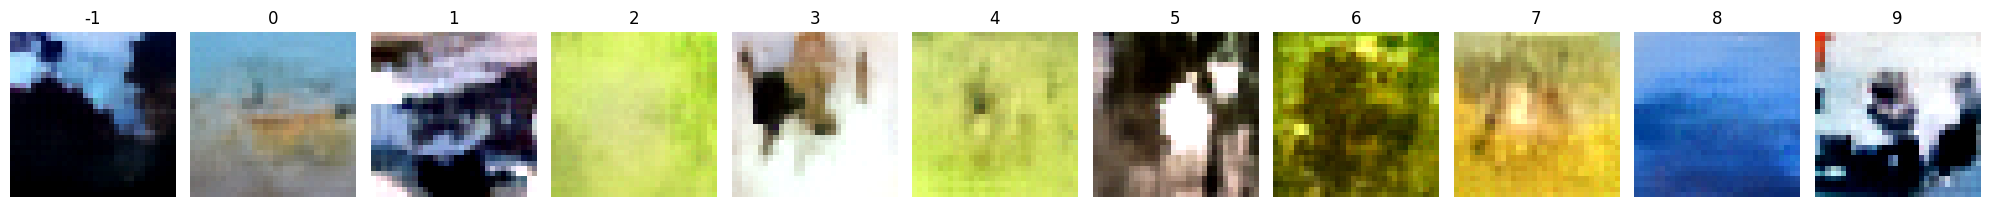

In [22]:
imgs = model.sample(add_null_label=True, scale=3.)
plot_images(imgs, has_null_label=True)

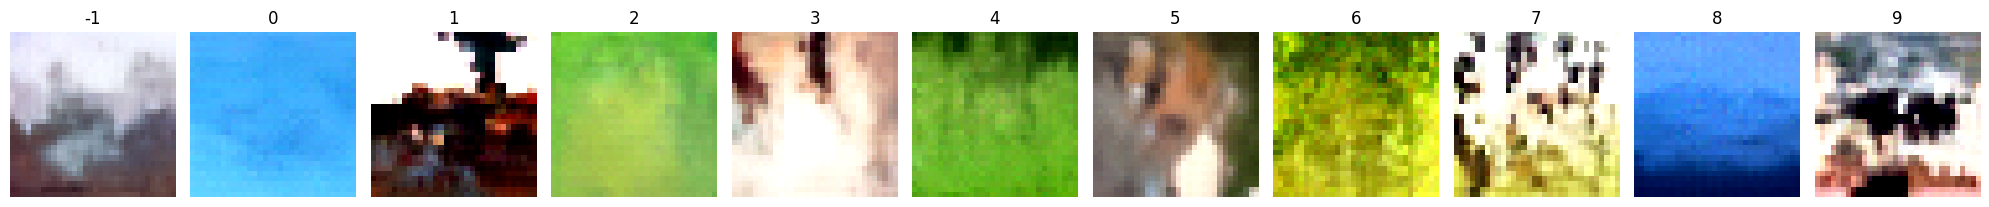

In [23]:
imgs = model.sample(add_null_label=True, scale=4.)
plot_images(imgs, has_null_label=True)

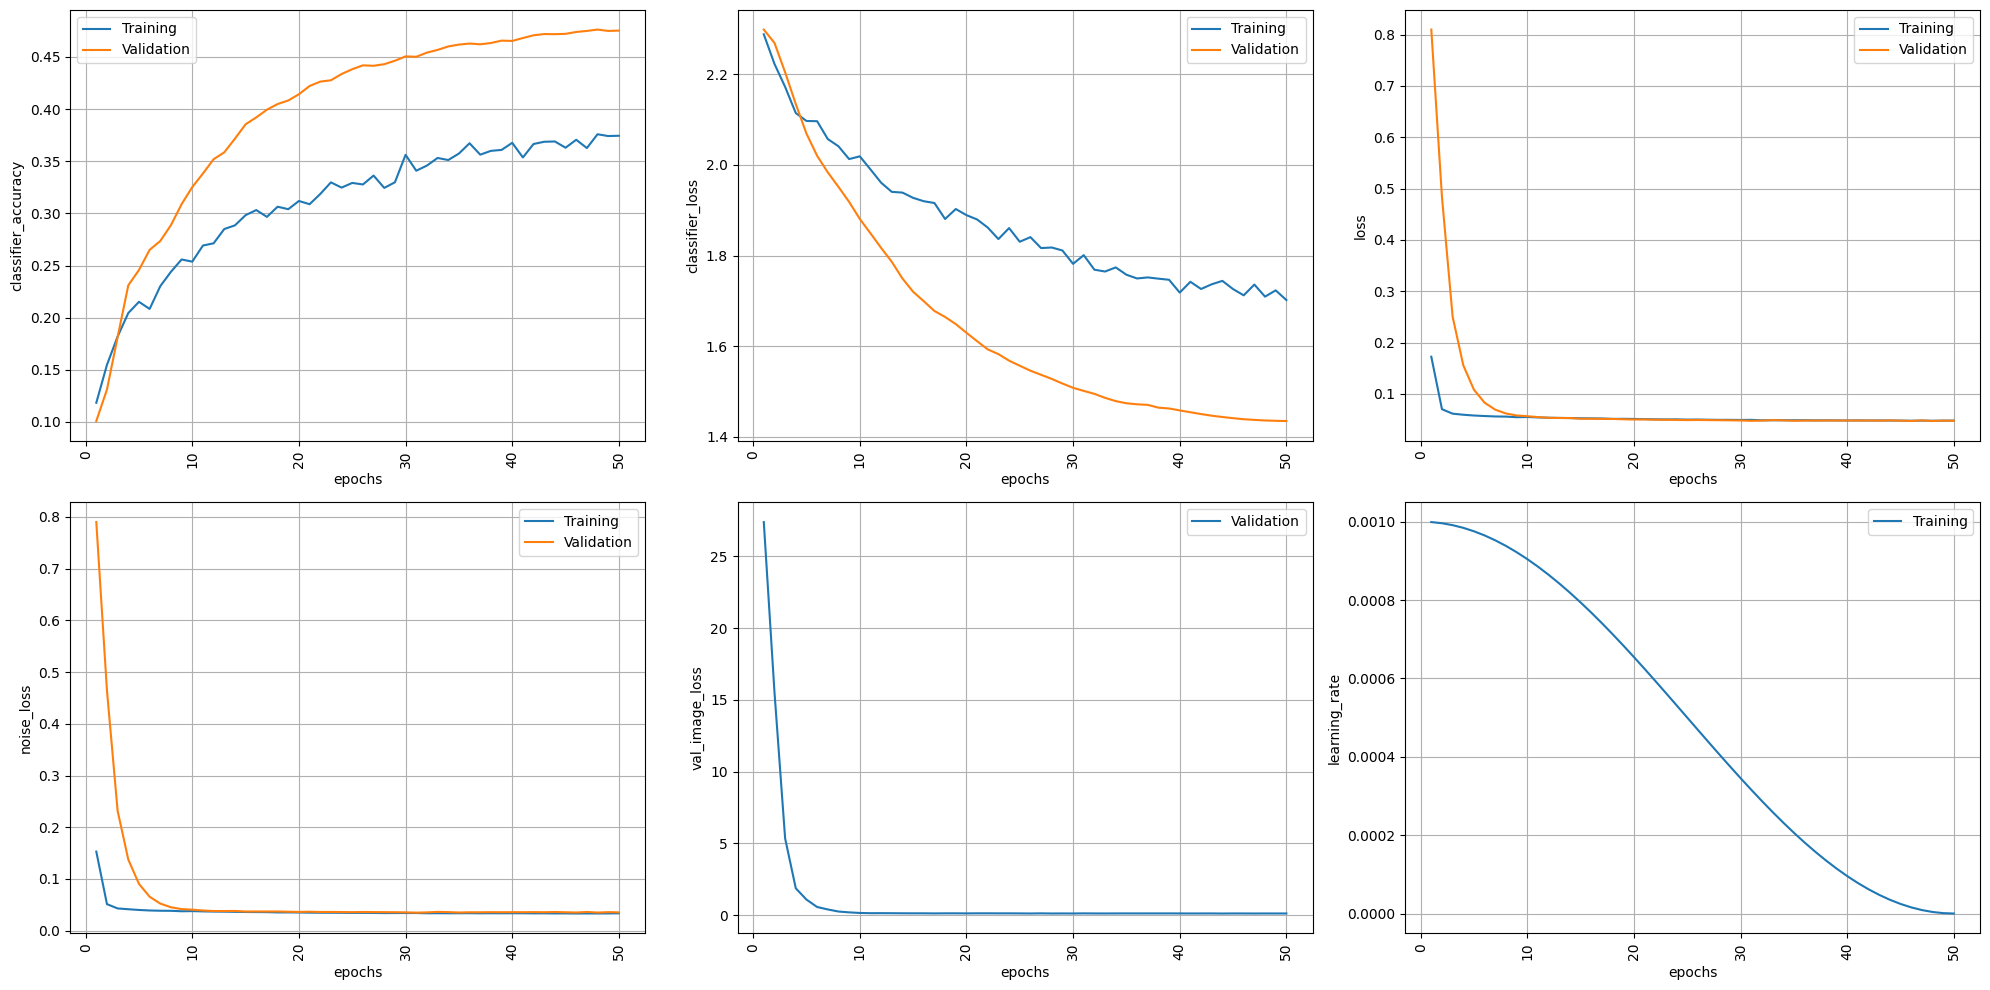

In [24]:
from common.utils import plot_history


plot_history(history, show_all_x_ticks=False)

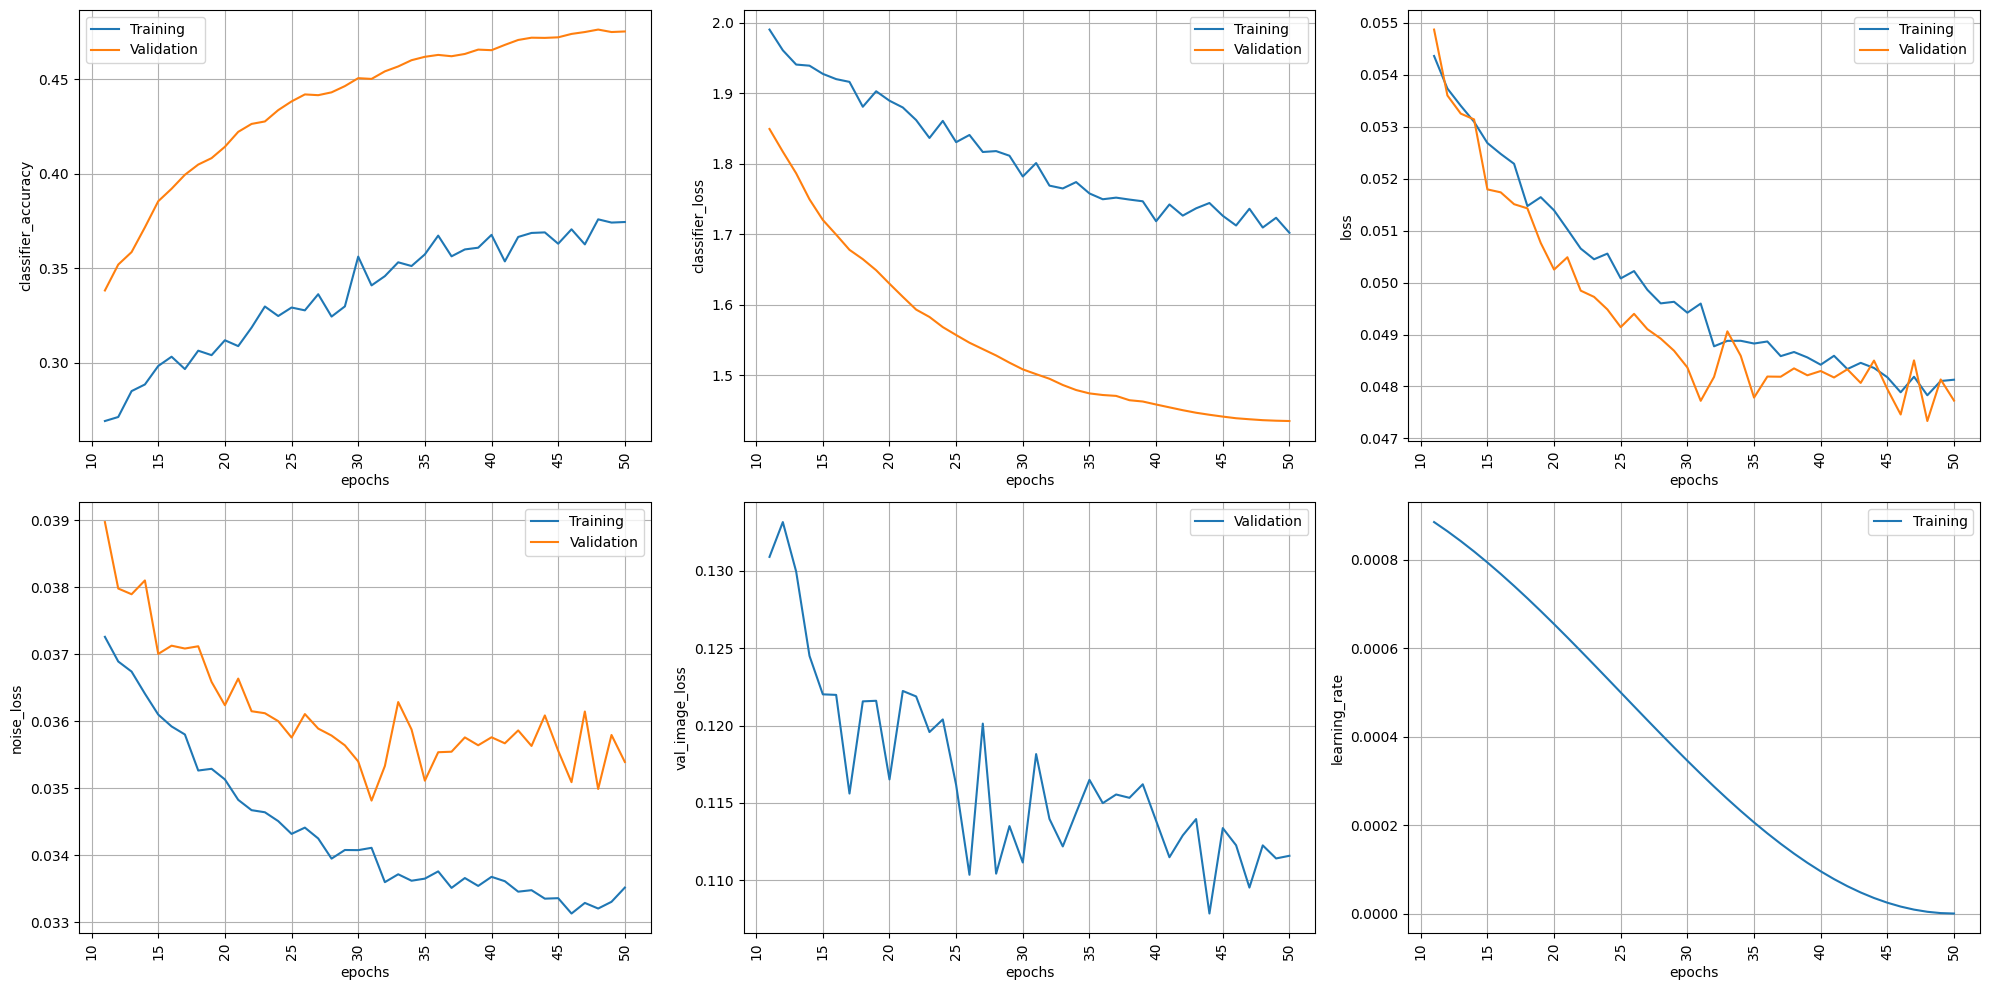

In [25]:
plot_history(history, show_all_x_ticks=False, range_=(10, None))